<!-- [reviewer-header] auto-generated; safe to keep at the top of the notebook -->


## Reviewer notes

**What this notebook does.** Pythia-70M appendix experiments: E1 baseline, R3 natural-vs-injected memorization, R3B multi-secret, R3C feasibility pilot, multi-seed LOO, random-init null, and probe-direction projection-out.

**Paper section.** §3.4 (causal separability), Appendix V (natural-vs-injected), Appendix W (probe-direction intervention), Appendix X (feasibility)

**Outputs.** 7 JSONs and 4 PNGs.

**Hardware / runtime.** T4 GPU, ~~60 min on T4.

**How to run from a fresh GitHub clone.**

1. Click the "Open in Colab" badge above (or upload to Kaggle / run locally).
2. The first code cell installs all dependencies via `pip`.
3. Output paths auto-detect the runtime: Colab Drive (`/content/drive/MyDrive/MIDU/`), Kaggle (`/kaggle/working/`), or a local `./mldu_e_work/` directory. No manual setup is required if you accept the defaults.
4. Mistral-7B notebooks additionally need an `HF_TOKEN` (Colab → Secrets, Kaggle → Add-ons → Secrets, or `os.environ['HF_TOKEN']` locally).

---


# Appendix Experiments Pipeline

**Runnable top-to-bottom.** Seven appendix experiments, each standalone but sharing the same setup.

## Sections

- **E1: Memorized vs Non-Memorized Baseline** (from `e1-memorized-vs-nonmemorized-probe.ipynb`)
- **R3: Natural-vs-Injected Probe** (from `r3-v2-with-early-stop.ipynb`)
- **R3B: Multi-Secret Injected Memorization** (from `r3b-injected-memorization-survives.ipynb`)
- **R3C: Unlearning Feasibility Pilot** (from `r3c-pilot-feasibility.ipynb`)
- **Multi-Seed LOO Stability** (from `multi-seed-loo-on-pythia-70m-2.ipynb`)
- **Random-Init Null Control** (from `random_init_control__1_.ipynb`)
- **Probe-Direction Intervention (Bridge)** (from `probe_direction_unlearn.ipynb`)

## Runtime

Each section loads its own Pythia-70M instance (fast; model is 70M params).
Total runtime: ~2-3 hours on Colab T4 / Kaggle T4.

## Outputs

Each section writes a JSON results file to the working directory. Inline seaborn/matplotlib figures render for each.


## 0. Setup

In [1]:
# Consolidated imports
import os, json, math, time, warnings, random
warnings.filterwarnings('ignore')

import numpy as np
import torch
import torch.nn.functional as F
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# Plotting
import matplotlib.pyplot as plt
try:
    import seaborn as sns
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'seaborn'])
    import seaborn as sns
sns.set_theme(style='whitegrid', context='notebook')

plt.rcParams.update({
    'figure.dpi': 110,
    'savefig.dpi': 200,
    'savefig.bbox': 'tight',
    'font.family': 'serif',
    'axes.titlesize': 12,
    'axes.labelsize': 11,
})

# Transformers
try:
    import transformers
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'transformers>=4.34'])
    import transformers
from transformers import AutoModelForCausalLM, AutoTokenizer

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
if DEVICE == 'cuda':
    for i in range(torch.cuda.device_count()):
        print(f'  [{i}] {torch.cuda.get_device_name(i)}')

# ============================================================================
# Environment detection + output directory
# ============================================================================
# Kaggle   -> /kaggle/working                    (persistent per-notebook)
# Colab    -> /content/drive/MyDrive/MLDU_outputs   (mounted Google Drive)
# Other    -> ./                                 (local cwd)
#
# Set USE_DRIVE = False to skip the Drive mount in Colab and use /content
# instead (faster, but ephemeral — files lost on runtime disconnect).
USE_DRIVE = True
DRIVE_SUBDIR = 'MLDU_outputs'   # folder name inside MyDrive

def _detect_env_and_setup_outdir():
    # Kaggle
    if os.path.exists('/kaggle/working'):
        return 'kaggle', '/kaggle/working'
    # Colab
    try:
        import google.colab  # noqa: F401
        in_colab = True
    except ImportError:
        in_colab = False
    if in_colab:
        if USE_DRIVE:
            from google.colab import drive
            if not os.path.ismount('/content/drive'):
                print('Mounting Google Drive... (authorize in the popup)')
                drive.mount('/content/drive')
            out = os.path.join('/content/drive/MyDrive', DRIVE_SUBDIR)
            os.makedirs(out, exist_ok=True)
            return 'colab+drive', out
        else:
            return 'colab', '/content'
    # Local / other
    return 'local', os.getcwd()

ENV, OUT_DIR = _detect_env_and_setup_outdir()
os.makedirs(OUT_DIR, exist_ok=True)
print(f'Environment: {ENV}')
print(f'Output directory: {OUT_DIR}')

Device: cuda
  [0] Tesla T4
  [1] Tesla T4
Environment: kaggle
Output directory: /kaggle/working


---

## 1. E1: Memorized vs Non-Memorized Baseline

**Source:** `e1-memorized-vs-nonmemorized-probe.ipynb`  
**About:** Basic probe baseline. Three conditions tested at every residual depth: C1 mem-vs-ctl (the intended test), C2 ctl-vs-ctl (null), C3 mem-vs-mem (null). Produces e1_results.json.

> Model loading happens inside this section. If you're running linearly, the previous section's model is cleaned up first.


In [2]:
# =============================================================================
# E1 — MEMORIZED vs NON-MEMORIZED PROBE
# =============================================================================
#
# WHY THIS EXPERIMENT
# -------------------
# The existing residual-stream probe compares
#     class 1: the same memorized string, repeated N times
#     class 0: N sentences drawn from a pool of ~16 background sentences
# Any two distinct strings are trivially linearly separable at every residual
# depth, so the probe does NOT measure memorization-specific structure —
# it measures input distinguishability. To fix this we introduce a
# NON-MEMORIZED CONTROL CLASS matched to the memorized class in:
#   - length (token count)
#   - domain / register (license-like text, web prose, code, etc.)
#   - surface vocabulary
#
# The control class is constructed by either:
#   (a) MODIFIED: taking memorized sequences and swapping distinctive terms
#       with plausible alternatives, producing text that is topically/lexically
#       similar but NOT memorized (verified via log P/tok screening).
#   (b) HELDOUT: sampling novel domain-matched text that the model has NOT
#       seen (or has very low probability of having seen) — verified with the
#       same log P screening used for the memorized class.
#
# THE KEY TEST
# ------------
# If probe(memorized vs non-memorized) >> probe(non-memorized-A vs
# non-memorized-B), then probe accuracy reflects memorization-specific
# structure rather than input distinguishability.
# If both are 1.000, the probe is reading surface input differences and
# the scaling finding does not support the "pre-computational separability"
# claim.
#
# We run THREE conditions per depth:
#   C1 — memorized      vs non-memorized (matched domain)    [main test]
#   C2 — non-memorized  vs non-memorized (within-matched)    [null]
#   C3 — memorized      vs memorized     (within-memorized)  [null]
#
# Expected results if the dissociation claim is correct:
#   C1: probe ≈ 1.000 at early depths (memorization signature exists)
#   C2: probe ≈ 0.500 (chance — non-memorized text has no signature)
#   C3: probe ≈ 0.500 (chance — all memorized texts share the signature)
#
# If C2 ≈ 1.000, the probe is reading input distinguishability and the
# current main-paper claim is NOT supported.
#
# MODEL: Mistral-7B (base). Same infrastructure as
# mistral-7b-natural-memorization-probe.ipynb. Adapt the MEMORIZED_POOL and
# CONTROL_POOL for GPT-2 medium and Pythia-70M by swapping model + tokenizer.
# =============================================================================

import os, json, time, random
import numpy as np
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForCausalLM
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)

# -----------------------------------------------------------------------------
# 1. MODEL
# -----------------------------------------------------------------------------
MODEL_NAME = 'mistralai/Mistral-7B-v0.1'
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.pad_token = tokenizer.eos_token
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME, torch_dtype=torch.float16,
    device_map='auto', output_hidden_states=True,
)
model.eval()
N_LAYERS = model.config.num_hidden_layers
D_MODEL  = model.config.hidden_size


# -----------------------------------------------------------------------------
# 2. MEMORIZED POOL (same as current Mistral notebook — already verified)
# -----------------------------------------------------------------------------
MEMORIZED_POOL = {
    'mit_license': (
        'Permission is hereby granted, free of charge, to any person obtaining '
        'a copy of this software and associated documentation files (the '
        '"Software"), to deal in the Software without restriction, including '
        'without limitation the rights to use, copy, modify, merge, publish, '
        'distribute, sublicense, and/or sell copies of the Software'
    ),
    'apache_license': (
        'Licensed under the Apache License, Version 2.0 (the "License"); '
        'you may not use this file except in compliance with the License. '
        'You may obtain a copy of the License at '
        'http://www.apache.org/licenses/LICENSE-2.0'
    ),
    'gpl_header': (
        'This program is free software: you can redistribute it and/or modify '
        'it under the terms of the GNU General Public License as published by '
        'the Free Software Foundation, either version 3 of the License, or '
        '(at your option) any later version.'
    ),
    'bsd_license': (
        'Redistribution and use in source and binary forms, with or without '
        'modification, are permitted provided that the following conditions '
        'are met: 1. Redistributions of source code must retain the above '
        'copyright notice, this list of conditions and the following disclaimer.'
    ),
    'creative_commons': (
        'This work is licensed under the Creative Commons Attribution 4.0 '
        'International License. To view a copy of this license, visit '
        'http://creativecommons.org/licenses/by/4.0/ or send a letter to '
        'Creative Commons, PO Box 1866, Mountain View, CA 94042, USA.'
    ),
    'lorem_ipsum': (
        'Lorem ipsum dolor sit amet, consectetur adipiscing elit, sed do '
        'eiusmod tempor incididunt ut labore et dolore magna aliqua. Ut enim '
        'ad minim veniam, quis nostrud exercitation ullamco laboris nisi ut '
        'aliquip ex ea commodo consequat.'
    ),
}

# -----------------------------------------------------------------------------
# 3. NON-MEMORIZED CONTROL POOL — CRUCIAL
# -----------------------------------------------------------------------------
# Each control is matched in:
#   - REGISTER: legal/license-like, prose, code, etc.
#   - LENGTH: within ±10 tokens of its memorized counterpart
#   - DISTINCTIVE VOCAB: retains some shared tokens (license, software, etc.)
#     so any residual "token-statistics" signal is shared with the memorized
#     class — this is the harder control.
#
# These are plausible-sounding but novel: newly-written or permuted enough
# that they are extremely unlikely to appear verbatim in Mistral's training.
# We VERIFY this via log P/tok screening (below) and keep only those with
# log P/tok < THRESH_NONMEM (much worse than the memorized class).
# -----------------------------------------------------------------------------
CONTROL_POOL = {
    'mit_like': (
        'Permission is explicitly denied, under all conditions, to any entity acquiring '
        'an instance of this software or its associated reference materials (the '
        '"Package"), to operate the Package under any restriction, barring the express '
        'limitation against rights to transfer, replicate, patch, consolidate, release, '
        'redistribute, relicense, or commercially exchange portions of the Package'
    ),
    'apache_like': (
        'Governed by the Mercantile Charter, Edition 3.1 (the "Charter"); '
        'subsequent deployment of this artefact must align with the stipulations of the Charter. '
        'A compliant transcript of the Charter is available via '
        'http://example.org/charters/MC-3.1'
    ),
    'gpl_like': (
        'This artefact constitutes shared cultural output: one may redistribute or augment '
        'it subject to the statutes of the Shared Output Charter as ratified by '
        'the Cultural Commons Assembly, edition four of the Charter, or '
        '(at the practitioner\'s discretion) any subsequent revision.'
    ),
    'bsd_like': (
        'Re-publication and reuse in textual and compiled forms, with or absent '
        'amendment, shall be allowed when the following stipulations '
        'are observed: 1. Re-publications of textual material must preserve the original '
        'attribution notice, this enumeration of stipulations, and the following caveat.'
    ),
    'cc_like': (
        'This artefact is governed by the Shared Cultural Attribution 3.0 '
        'Continental Charter. For a transcript of the charter consult '
        'http://example.org/charters/SCA-3.0 or dispatch correspondence to '
        'Shared Culture, PO Box 9999, Riverside, OR 97000, USA.'
    ),
    'lorem_like': (
        'Kelp arium folio stat nullam, contextus adipisci erat, sic quo '
        'primum labor deficit ut veluti et libenter magna aurea. Ut altum '
        'ad maximum partem, sic potens nostrum declamatio ullamco vinculis nisi ut '
        'acquir ex partibus corpus convenit.'
    ),
}

# -----------------------------------------------------------------------------
# 4. LOG-P SCREENING — verify memorized/control classes really differ
# -----------------------------------------------------------------------------
def log_p_per_token(text, max_tokens=128):
    inputs = tokenizer(text, return_tensors='pt', truncation=True,
                       max_length=max_tokens).to(model.device)
    ids = inputs['input_ids']
    with torch.no_grad():
        logits = model(**inputs).logits
    log_probs = F.log_softmax(logits[0, :-1, :], dim=-1)
    tok_lp = log_probs[torch.arange(ids.shape[1]-1), ids[0, 1:]]
    return tok_lp.float().mean().item()

print('=' * 72)
print('STEP 1 — LOG-P SCREENING')
print('Memorized pool should have log P/tok > -1.0')
print('Control pool should have log P/tok < -2.5 (not memorized)')
print('=' * 72)

mem_logp = {k: log_p_per_token(v) for k, v in MEMORIZED_POOL.items()}
ctl_logp = {k: log_p_per_token(v) for k, v in CONTROL_POOL.items()}

print('\nMEMORIZED:')
for k, lp in mem_logp.items():
    flag = '✓ mem'   if lp > -1.0 else '✗ WEAK'
    print(f'  {k:<25} log P/tok = {lp:7.3f}  [{flag}]')

print('\nCONTROL:')
for k, lp in ctl_logp.items():
    flag = '✓ not-mem' if lp < -2.5 else '✗ TOO-LIKELY'
    print(f'  {k:<25} log P/tok = {lp:7.3f}  [{flag}]')

# Only keep pairs where both screening tests pass
valid_pairs = []
for m_key in MEMORIZED_POOL:
    # pair each memorized seq with its matched-register control
    c_key = m_key.replace('_license', '_like').replace('_header','_like') \
                 .replace('_ipsum','_like').replace('_commons','_like')
    if c_key not in CONTROL_POOL: continue
    if mem_logp[m_key] > -1.0 and ctl_logp[c_key] < -2.5:
        valid_pairs.append((m_key, c_key))
print(f'\nValid (memorized, control) pairs: {len(valid_pairs)}')


# -----------------------------------------------------------------------------
# 5. RESIDUAL EXTRACTION + PROBE (re-use existing signatures)
# -----------------------------------------------------------------------------
MAX_TOKENS = 64

def resid_at_depth(text, depth):
    inputs = tokenizer(text, return_tensors='pt',
                       truncation=True, max_length=MAX_TOKENS).to(model.device)
    with torch.no_grad():
        h = model(**inputs, output_hidden_states=True).hidden_states[depth]
    return h[0, -1, :].float().cpu().numpy()

def probe_acc(X0, X1):
    X = np.vstack([X0, X1])
    y = np.array([0]*len(X0) + [1]*len(X1))
    Xtr, Xte, ytr, yte = train_test_split(
        X, y, test_size=0.3, random_state=SEED, stratify=y)
    sc = StandardScaler(); Xtr = sc.fit_transform(Xtr); Xte = sc.transform(Xte)
    clf = LogisticRegression(max_iter=1000, C=1.0, random_state=SEED)
    clf.fit(Xtr, ytr)
    return accuracy_score(yte, clf.predict(Xte))


# -----------------------------------------------------------------------------
# 6. VARIANCE INJECTION — the second fix
# -----------------------------------------------------------------------------
# A single input string produces one deterministic activation vector in
# model.eval() mode. To get a non-degenerate sample we need meaningful
# variation WITHIN each class. We use three complementary strategies:
#
#   (a) PREFIX-SUFFIX PERTURBATIONS: prepend/append short neutral phrases
#       so the model sees the memorized text in slightly varying contexts
#   (b) WHITESPACE-NEUTRAL PERTURBATIONS: minor formatting tweaks that
#       preserve text content but change tokenization minimally
#   (c) POSITION SHIFTS: prepend varying amounts of neutral filler so the
#       memorized content appears at different absolute positions
#
# These produce genuinely distinct activation vectors for the same
# underlying sequence — while preserving what we mean by "the same memorized
# content." This addresses the deterministic-duplicate problem.
# -----------------------------------------------------------------------------
PREFIXES = [
    '', 'Note: ', 'See below: ', 'Consider this: ', 'Relevant: ',
    'From the docs: ', 'Excerpt: ', 'Quoting: ', 'As written: ',
    'Reference text: ', 'Verbatim: ', 'Cited below: ',
    'The following: ', 'Extract: ', 'Observed: ', 'Per the record: ',
]

def make_variants(base_text, n):
    """Generate N distinct but semantically-equivalent variants."""
    variants = []
    for i in range(n):
        pref = PREFIXES[i % len(PREFIXES)]
        variants.append(pref + base_text)
    return variants

# Sanity check: variants should produce non-identical activations
if len(valid_pairs) > 0:
    m_key, _ = valid_pairs[0]
    v = make_variants(MEMORIZED_POOL[m_key], 4)
    r0 = resid_at_depth(v[0], depth=1)
    r1 = resid_at_depth(v[1], depth=1)
    dist = float(np.linalg.norm(r0 - r1))
    print(f'\nVariance check: L2 distance between variant activations = {dist:.3f}')
    print('(Should be > 0; if 0, variants are collapsing to same tokenization)')


# -----------------------------------------------------------------------------
# 7. MAIN EXPERIMENT — three conditions at each depth
# -----------------------------------------------------------------------------
N_PER_CLASS  = 48       # samples per class; 48 = 3×16 prefixes, balanced
DEPTHS_TO_PROBE = list(range(0, N_LAYERS+1))   # all depths

results = { 'C1_mem_vs_ctl': {}, 'C2_ctl_vs_ctl': {}, 'C3_mem_vs_mem': {} }

def collect_reps(texts, depth):
    return np.array([resid_at_depth(t, depth) for t in texts])

print('\n' + '=' * 72)
print('STEP 2 — THREE-CONDITION PROBE')
print('=' * 72)

t_all = time.time()
for pair_i, (m_key, c_key) in enumerate(valid_pairs):
    m_text = MEMORIZED_POOL[m_key]
    c_text = CONTROL_POOL[c_key]
    m_vars = make_variants(m_text, N_PER_CLASS)
    c_vars = make_variants(c_text, N_PER_CLASS)

    # For within-class conditions we need a SECOND memorized/control text
    # to pair against the first. Use the next pair in the cycle.
    m2_key, c2_key = valid_pairs[(pair_i + 1) % len(valid_pairs)]
    m2_vars = make_variants(MEMORIZED_POOL[m2_key], N_PER_CLASS)
    c2_vars = make_variants(CONTROL_POOL[c2_key],   N_PER_CLASS)

    print(f'\nPair {pair_i+1}/{len(valid_pairs)}: '
          f'{m_key} (mem) vs {c_key} (ctl)')
    print(f'           within-class pair: {m2_key} / {c2_key}')

    for name, (texts_0, texts_1) in {
        'C1_mem_vs_ctl':  (m_vars,  c_vars),   # main test
        'C2_ctl_vs_ctl':  (c_vars,  c2_vars),  # null-1: two non-mem texts
        'C3_mem_vs_mem':  (m_vars,  m2_vars),  # null-2: two mem texts
    }.items():
        for depth in DEPTHS_TO_PROBE:
            X0 = collect_reps(texts_0, depth)
            X1 = collect_reps(texts_1, depth)
            acc = probe_acc(X0, X1)
            results[name].setdefault(m_key, {})[depth] = acc
    # Progress every pair
    for name in results:
        d0_acc = results[name][m_key][0]
        min_acc = min(results[name][m_key].values())
        print(f'    {name:<16} embed={d0_acc:.3f}  min-over-depths={min_acc:.3f}')

print(f'\nTotal elapsed: {(time.time()-t_all)/60:.1f} min')


# -----------------------------------------------------------------------------
# 8. INTERPRETATION
# -----------------------------------------------------------------------------
print('\n' + '=' * 72)
print('INTERPRETATION')
print('=' * 72)
# Compute summary across all sequences
for name in results:
    all_vals = [v for seq in results[name].values() for v in seq.values()]
    mean_acc = np.mean(all_vals)
    frac_high = np.mean([v >= 0.95 for v in all_vals])
    print(f'  {name:<16} mean={mean_acc:.3f}  frac≥0.95={frac_high:.2f}')

print('''
How to read this:
  If C1 >> C2 and C1 >> C3    → probe is memorization-specific (CLAIM HOLDS)
  If C1 ≈ C2 (both ≈ 1.000)   → probe reads input distinguishability
                                 (CLAIM FAILS — need to revise paper)
  If C1 ≈ C3 (both ≈ 0.5)     → no detectable memorization signature at
                                 this depth — still a valid finding but
                                 very different story
''')

# Save
os.makedirs(OUT_DIR, exist_ok=True)
with open('/kaggle/working/E1_results.json', 'w') as f:
    json.dump({
        'model': MODEL_NAME,
        'valid_pairs': valid_pairs,
        'memorized_logp': mem_logp,
        'control_logp': ctl_logp,
        'probe_results': {k: {m: {str(d): v for d, v in seq.items()}
                              for m, seq in pair.items()}
                          for k, pair in results.items()},
    }, f, indent=2)
print('Saved: /kaggle/working/E1_results.json')

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/996 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

...

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['output_hidden_states']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

STEP 1 — LOG-P SCREENING
Memorized pool should have log P/tok > -1.0
Control pool should have log P/tok < -2.5 (not memorized)

MEMORIZED:
  mit_license               log P/tok =  -0.276  [✓ mem]
  apache_license            log P/tok =  -0.431  [✓ mem]
  gpl_header                log P/tok =  -0.512  [✓ mem]
  bsd_license               log P/tok =  -0.469  [✓ mem]
  creative_commons          log P/tok =  -0.344  [✓ mem]
  lorem_ipsum               log P/tok =  -0.216  [✓ mem]

CONTROL:
  mit_like                  log P/tok =  -3.387  [✓ not-mem]
  apache_like               log P/tok =  -2.796  [✓ not-mem]
  gpl_like                  log P/tok =  -3.742  [✓ not-mem]
  bsd_like                  log P/tok =  -2.951  [✓ not-mem]
  cc_like                   log P/tok =  -2.948  [✓ not-mem]
  lorem_like                log P/tok =  -4.800  [✓ not-mem]

Valid (memorized, control) pairs: 5

Variance check: L2 distance between variant activations = 0.285
(Should be > 0; if 0, variants are collap

In [3]:
output_path = os.path.join(OUT_DIR, 'E1_results.json')

with open(output_path, 'w') as f:
    json.dump({
        'model': MODEL_NAME,
        'valid_pairs': valid_pairs,
        'memorized_logp': mem_logp,
        'control_logp': ctl_logp,
        'probe_results': {
            k: {
                m: {str(d): v for d, v in seq.items()}
                for m, seq in pair.items()
            }
            for k, pair in results.items()
        },
    }, f, indent=2)

print(f'Saved: {output_path}')

Saved: /kaggle/working/E1_results.json


*End of section 1. — memory cleanup before next section.*

In [4]:
# Cleanup between sections
for _n in ['model', 'tokenizer', 'base_model', 'mem_res', 'ctl_res',
           'pure_a_res', 'pure_b_res']:
    if _n in dir():
        try:
            exec(f'del {_n}')
        except Exception:
            pass
import gc
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

---

## 2. R3: Natural-vs-Injected Probe

**Source:** `r3-v2-with-early-stop.ipynb`  
**About:** Tests whether a probe trained on naturally memorized sequences recognizes fine-tuning-injected secrets. Uses early stopping on target log-P. Produces r3_results.json.

> Model loading happens inside this section. If you're running linearly, the previous section's model is cleaned up first.


In [5]:
# =============================================================================
# PROBE_CORE — embedded at top of notebook so you don't need to upload files.
# Run this cell first.
# =============================================================================

"""
probe_core.py — Shared utilities for all revision experiments (R1-R5).

Any HF causal LM that exposes hidden_states works. Tested on:
  - mistralai/Mistral-7B-v0.1
  - gpt2-medium
  - EleutherAI/pythia-70m

Drop this file next to each experiment notebook. Every R{n} experiment
imports from here so pools, contexts, and screening are consistent.
"""

import os, time, random
import numpy as np
import torch
import torch.nn.functional as F
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

SEED = 42


# =============================================================================
# POOLS — four memorized categories for scope expansion
# =============================================================================
# The Mistral E3 result showed the LOO signature generalizes well across the
# legal-license cluster (MIT, Apache, GPL, BSD) but breaks down for lorem
# ipsum (Latin placeholder text). To characterize scope, we now include:
#
#   - LEGAL LICENSES (cluster 1): shared register, overlapping vocab
#   - CODE BOILERPLATE (cluster 2): different register, programming tokens
#   - WEB/REFERENCE PROSE (cluster 3): different register, encyclopedic
#   - PLACEHOLDER TEXT (cluster 4): pseudo-Latin — the known outlier
#
# For each memorized sequence we construct a matched non-memorized control
# by substituting distinctive terms (preserving register and length) so that
# log P/tok drops below -2.5 while the surface form stays plausible.
# =============================================================================

POOL_M = {
    # --- legal licenses (cluster 1) ---
    'mit_license': (
        'Permission is hereby granted, free of charge, to any person obtaining '
        'a copy of this software and associated documentation files (the '
        '"Software"), to deal in the Software without restriction, including '
        'without limitation the rights to use, copy, modify, merge, publish, '
        'distribute, sublicense, and/or sell copies of the Software'
    ),
    'apache_license': (
        'Licensed under the Apache License, Version 2.0 (the "License"); '
        'you may not use this file except in compliance with the License. '
        'You may obtain a copy of the License at '
        'http://www.apache.org/licenses/LICENSE-2.0'
    ),
    'gpl_header': (
        'This program is free software: you can redistribute it and/or modify '
        'it under the terms of the GNU General Public License as published by '
        'the Free Software Foundation, either version 3 of the License, or '
        '(at your option) any later version.'
    ),
    'bsd_license': (
        'Redistribution and use in source and binary forms, with or without '
        'modification, are permitted provided that the following conditions '
        'are met: 1. Redistributions of source code must retain the above '
        'copyright notice, this list of conditions and the following disclaimer.'
    ),
    # --- code boilerplate (cluster 2) ---
    'shebang_python': (
        '#!/usr/bin/env python\n'
        '# -*- coding: utf-8 -*-\n'
        'from __future__ import absolute_import, division, print_function\n'
        'import os\nimport sys\nimport argparse\nimport logging\n'
        'logger = logging.getLogger(__name__)'
    ),
    'python_main': (
        'if __name__ == "__main__":\n'
        '    parser = argparse.ArgumentParser()\n'
        '    parser.add_argument("--input", type=str, required=True)\n'
        '    parser.add_argument("--output", type=str, default="output")\n'
        '    args = parser.parse_args()\n'
        '    main(args)'
    ),
    # --- web/reference prose (cluster 3) ---
    'wikipedia_python': (
        'Python is a high-level, general-purpose programming language. Its '
        'design philosophy emphasizes code readability with the use of '
        'significant indentation. Python is dynamically typed and '
        'garbage-collected.'
    ),
    'creative_commons': (
        'This work is licensed under the Creative Commons Attribution 4.0 '
        'International License. To view a copy of this license, visit '
        'http://creativecommons.org/licenses/by/4.0/'
    ),
    # --- placeholder text (cluster 4) ---
    'lorem_ipsum': (
        'Lorem ipsum dolor sit amet, consectetur adipiscing elit, sed do '
        'eiusmod tempor incididunt ut labore et dolore magna aliqua. Ut enim '
        'ad minim veniam, quis nostrud exercitation ullamco laboris nisi ut '
        'aliquip ex ea commodo consequat.'
    ),
}

POOL_C = {
    # --- legal licenses: register-matched, distinctive-term-swapped ---
    'mit_license': (
        'Permission is explicitly denied, under all conditions, to any entity acquiring '
        'an instance of this software or its associated reference materials (the '
        '"Package"), to operate the Package under any restriction, barring the express '
        'limitation against rights to transfer, replicate, patch, consolidate, release, '
        'redistribute, relicense, or commercially exchange portions of the Package'
    ),
    'apache_license': (
        'Governed by the Mercantile Charter, Edition 3.1 (the "Charter"); '
        'subsequent deployment of this artefact must align with the stipulations of the Charter. '
        'A compliant transcript of the Charter is available via '
        'http://example.org/charters/MC-3.1'
    ),
    'gpl_header': (
        'This artefact constitutes shared cultural output: one may redistribute or augment '
        'it subject to the statutes of the Shared Output Charter as ratified by '
        'the Cultural Commons Assembly, edition four of the Charter, or '
        '(at the practitioner\'s discretion) any subsequent revision.'
    ),
    'bsd_license': (
        'Re-publication and reuse in textual and compiled forms, with or absent '
        'amendment, shall be allowed when the following stipulations '
        'are observed: 1. Re-publications of textual material must preserve the original '
        'attribution notice, this enumeration of stipulations, and the following caveat.'
    ),
    # --- code controls: syntactically valid but unusual ---
    'shebang_python': (
        '#!/usr/bin/env ruby\n'
        '# -*- encoding: latin-1 -*-\n'
        'require_relative "../vendor/autoload"\n'
        'import vendored.parser as vparser\n'
        'import vendored.logger\n'
        'log_instance = vendored.logger.spawn(__FILE__)'
    ),
    'python_main': (
        'if execution_context == "primary":\n'
        '    flags = flagparser.DeclarativeParser()\n'
        '    flags.declare_entry("--source", kind=text, requisite=True)\n'
        '    flags.declare_entry("--destination", kind=text, fallback="result")\n'
        '    options = flags.finalize_parse()\n'
        '    dispatch_primary(options)'
    ),
    # --- web/reference controls: structurally similar, factually different ---
    'wikipedia_python': (
        'Rutherix is a mid-level, application-bound scripting dialect. Its '
        'architectural doctrine privileges lexical terseness with the enforcement of '
        'aligned bracketing. Rutherix is statically audited and '
        'manually refcounted.'
    ),
    'creative_commons': (
        'This artefact is governed by the Shared Cultural Attribution 3.0 '
        'Continental Charter. For a transcript of the charter consult '
        'http://example.org/charters/SCA-3.0'
    ),
    # --- placeholder control ---
    'lorem_ipsum': (
        'Kelp arium folio stat nullam, contextus adipisci erat, sic quo '
        'primum labor deficit ut veluti et libenter magna aurea. Ut altum '
        'ad maximum partem, sic potens nostrum declamatio ullamco vinculis nisi ut '
        'acquir ex partibus corpus convenit.'
    ),
}

# Second non-memorized pool for pure-distinguishability baseline.
POOL_B = {
    'mit_license': (
        'Authorization is hereby withheld, universally and permanently, from every recipient holding '
        'an archival copy of this module or its accompanying annotation files (the '
        '"Manifest"), to interact with the Manifest under any exemption, including the explicit '
        'waiver of privileges to propagate, annotate, restructure, aggregate, broadcast, '
        'redistribute, revoke, or contractually transfer fragments of the Manifest'
    ),
    'apache_license': (
        'Administered by the Consortial Directive, Revision 8.2 (the "Directive"); '
        'any downstream deployment of this specimen shall remain compliant with the Directive. '
        'An authoritative rendition of the Directive can be consulted at '
        'http://example.org/directives/CD-8.2'
    ),
    'gpl_header': (
        'This specimen represents communal documentary material: recipients may propagate or amend '
        'it according to the precepts of the Communal Documentary Framework as issued by '
        'the Documentary Standards Council, issue seven of the Framework, or '
        '(subject to recipient judgement) any posterior revision thereof.'
    ),
    'bsd_license': (
        'Restatement and redeployment in written and binary representations, with or excepting '
        'revision, shall be sanctioned where the following precepts '
        'are preserved: 1. Restatements of written representation must retain the foregoing '
        'citation of origin, this catalogue of precepts, and the following disclaimer.'
    ),
    'shebang_python': (
        '#!/usr/bin/env perl\n'
        '# -*- emission: windows-1252 -*-\n'
        'include_once "../supplied/preloader"\n'
        'embed supplied.processor as eprocessor\n'
        'embed supplied.tracer\n'
        'trace_node = supplied.tracer.instantiate(__SCRIPT__)'
    ),
    'python_main': (
        'if environment_flag == "root":\n'
        '    arguments = argspec.ImperativeSpec()\n'
        '    arguments.register_slot("--origin", variety=word, mandatory=True)\n'
        '    arguments.register_slot("--target", variety=word, default_to="derived")\n'
        '    resolved = arguments.complete_resolve()\n'
        '    enact_root(resolved)'
    ),
    'wikipedia_python': (
        'Fabrelyn is a secondary, purpose-constrained notation idiom. Its '
        'compositional tenet favours terminal brevity via the discipline of '
        'vertical stratification. Fabrelyn is runtime-verified and '
        'cooperatively reclaimed.'
    ),
    'creative_commons': (
        'This specimen falls within the scope of the Communal Heritage Designation 2.0 '
        'Continental Concord. To access the concord\'s provisions consult '
        'http://example.org/concords/CHD-2.0'
    ),
    'lorem_ipsum': (
        'Mentat ipsum solea sed inebriat, convictus aequipollens erit, non tum '
        'prior laboro declinat et sperata et inanes magna obscura. Sub alto '
        'ad summum fragmentum, non validus nostrum oratio ullamco catenis nisi et '
        'obtinet ex segmentis stipulatio assensum.'
    ),
}

assert set(POOL_M.keys()) == set(POOL_C.keys()) == set(POOL_B.keys())

CLUSTER_MAP = {
    'mit_license':    'legal',
    'apache_license': 'legal',
    'gpl_header':     'legal',
    'bsd_license':    'legal',
    'shebang_python': 'code',
    'python_main':    'code',
    'wikipedia_python': 'web',
    'creative_commons': 'web',
    'lorem_ipsum':    'placeholder',
}


# =============================================================================
# NEUTRAL CONTEXTS for within-class variance
# =============================================================================
NEUTRAL_CONTEXTS = [
    "Here is a passage: ",       "A document contains: ",     "Someone shared: ",
    "I copied this: ",           "From a book: ",             "Below is a snippet: ",
    "The document begins: ",     "An archived message: ",     "The paragraph states: ",
    "A clipboard entry: ",       "The transcript records: ",  "An earlier note: ",
    "The preface reads: ",       "A footnote provides: ",     "According to record: ",
    "The memo opens: ",          "In the margin: ",           "The cover letter: ",
    "The archive entry: ",       "A clipping mentions: ",     "The letter continues: ",
    "The dispatch read: ",       "The annotation: ",          "The bulletin noted: ",
]


# =============================================================================
# LOG-P SCREENING
# =============================================================================
def log_p_per_token(model, tokenizer, text, max_tokens=96):
    """Mean log probability per token — used to verify memorization status."""
    inp = tokenizer(text, return_tensors='pt', truncation=True,
                    max_length=max_tokens).to(model.device)
    ids = inp['input_ids']
    with torch.no_grad():
        logits = model(**inp).logits
    lp = F.log_softmax(logits[0, :-1, :], dim=-1)
    return lp[torch.arange(ids.shape[1]-1), ids[0, 1:]].float().mean().item()


def screen_pools(model, tokenizer, mem_thresh=-1.0, ctl_thresh=-2.5,
                 pools=None, verbose=True):
    """Return dict of keys that pass screening in both M and C pools."""
    if pools is None:
        pools = (POOL_M, POOL_C, POOL_B)
    M, C, B = pools

    if verbose:
        print(f'{"key":<20} {"mem":<8} {"ctl":<8} {"B":<8}  verdict')
        print('-' * 60)

    valid = []
    results = {}
    for k in M:
        mlp = log_p_per_token(model, tokenizer, M[k])
        clp = log_p_per_token(model, tokenizer, C[k])
        blp = log_p_per_token(model, tokenizer, B[k])
        ok = mlp > mem_thresh and clp < ctl_thresh and blp < ctl_thresh
        results[k] = {'mem_logp': mlp, 'ctl_logp': clp, 'B_logp': blp, 'valid': ok}
        if ok:
            valid.append(k)
        if verbose:
            mark = '\u2713' if ok else '\u2717'
            print(f'{k:<20} {mlp:<8.3f} {clp:<8.3f} {blp:<8.3f}  {mark}')

    if verbose:
        print(f'\nValid pairs: {len(valid)}/{len(M)}')
    return valid, results


# =============================================================================
# RESIDUAL EXTRACTION
# =============================================================================
def extract_residual(model, tokenizer, text, depth, max_tokens=96):
    """Residual stream at `depth` (0 = embedding, k = output of layer k-1)
    at the last non-padding token position.
    """
    inp = tokenizer(text, return_tensors='pt', truncation=True,
                    max_length=max_tokens).to(model.device)
    with torch.no_grad():
        hs = model(**inp, output_hidden_states=True).hidden_states
    return hs[depth][0, -1, :].float().cpu().numpy()


def extract_all_depths(model, tokenizer, text, max_tokens=96):
    """Return (n_depths, d_model) numpy array — efficient single forward pass."""
    inp = tokenizer(text, return_tensors='pt', truncation=True,
                    max_length=max_tokens).to(model.device)
    with torch.no_grad():
        hs = model(**inp, output_hidden_states=True).hidden_states
    return np.stack([h[0, -1, :].float().cpu().numpy() for h in hs])


def extract_pool_residuals(model, tokenizer, keys, pool_m, pool_c, pool_b=None,
                           contexts=None, max_tokens=96, verbose=True):
    """Extract residuals at all depths for every key x class x context combo.

    Returns nested dict: reps[key][class_name] = array (n_contexts, n_depths, d_model)
    """
    if contexts is None:
        contexts = NEUTRAL_CONTEXTS

    n_ctx = len(contexts)
    reps = {}
    t0 = time.time()
    for key in keys:
        reps[key] = {}
        payloads = {'mem': pool_m[key], 'ctl': pool_c[key]}
        if pool_b is not None:
            payloads['B'] = pool_b[key]

        for cls, payload in payloads.items():
            per_ctx = []
            for ctx in contexts:
                per_ctx.append(extract_all_depths(model, tokenizer, ctx + payload,
                                                  max_tokens=max_tokens))
            reps[key][cls] = np.stack(per_ctx)   # (n_ctx, n_depths, d_model)
        if verbose:
            print(f'  {key}: done  [{(time.time()-t0)/60:.1f} min]')
    return reps


# =============================================================================
# LOO PROBE
# =============================================================================
def loo_accuracy(reps_dict, keys, depth, class_pos='mem', class_neg='ctl',
                 random_state=SEED):
    """Leave-one-out cross-sequence accuracy at a given depth.

    Trains a probe to distinguish `class_pos` from `class_neg` using all
    sequences except the held-out one, tests on the held-out sequence.
    """
    n_ctx = reps_dict[keys[0]][class_pos].shape[0]
    per_seq = {}
    for held_out in keys:
        train_keys = [k for k in keys if k != held_out]
        X_tr, y_tr = [], []
        for k in train_keys:
            X_tr.append(reps_dict[k][class_pos][:, depth, :]); y_tr += [1]*n_ctx
            X_tr.append(reps_dict[k][class_neg][:, depth, :]); y_tr += [0]*n_ctx
        X_tr = np.vstack(X_tr); y_tr = np.array(y_tr)

        X_te = np.vstack([
            reps_dict[held_out][class_pos][:, depth, :],
            reps_dict[held_out][class_neg][:, depth, :],
        ])
        y_te = np.array([1]*n_ctx + [0]*n_ctx)

        sc = StandardScaler()
        X_tr = sc.fit_transform(X_tr); X_te = sc.transform(X_te)
        clf = LogisticRegression(max_iter=2000, C=1.0, random_state=random_state)
        clf.fit(X_tr, y_tr)
        per_seq[held_out] = float(accuracy_score(y_te, clf.predict(X_te)))
    vals = list(per_seq.values())
    return float(np.mean(vals)), float(np.std(vals)), per_seq


def loo_accuracy_shuffled(reps_dict, keys, depth, rng,
                          class_pos='mem', class_neg='ctl'):
    """LOO with randomly flipped class assignments per sequence.
    If true LOO is real signal, shuffled drops to ~0.5.
    """
    n_ctx = reps_dict[keys[0]][class_pos].shape[0]
    shuffled = {k: list(rng.permutation([class_pos, class_neg])) for k in keys}

    per_seq = {}
    for held_out in keys:
        train_keys = [k for k in keys if k != held_out]
        X_tr, y_tr = [], []
        for k in train_keys:
            lbl_pos, lbl_neg = shuffled[k]
            X_tr.append(reps_dict[k][lbl_pos][:, depth, :]); y_tr += [1]*n_ctx
            X_tr.append(reps_dict[k][lbl_neg][:, depth, :]); y_tr += [0]*n_ctx
        X_tr = np.vstack(X_tr); y_tr = np.array(y_tr)
        lbl_pos, lbl_neg = shuffled[held_out]
        X_te = np.vstack([
            reps_dict[held_out][lbl_pos][:, depth, :],
            reps_dict[held_out][lbl_neg][:, depth, :],
        ])
        y_te = np.array([1]*n_ctx + [0]*n_ctx)

        sc = StandardScaler()
        X_tr = sc.fit_transform(X_tr); X_te = sc.transform(X_te)
        clf = LogisticRegression(max_iter=2000, C=1.0, random_state=SEED)
        clf.fit(X_tr, y_tr)
        per_seq[held_out] = float(accuracy_score(y_te, clf.predict(X_te)))
    return float(np.mean(list(per_seq.values()))), per_seq


In [6]:
# =============================================================================
# R3 — DOES THE CROSS-SEQUENCE SIGNATURE SURVIVE UNLEARNING?
# =============================================================================
#
# THIS IS THE MOST IMPORTANT EXPERIMENT IN THE REVISION
# ----------------------------------------------------
# E3 established that a cross-sequence memorization signature exists in
# residual stream activations at mid-network depths. But the paper's CENTRAL
# CLAIM is not just that the signature exists — it's that the signature
# SURVIVES head-level unlearning. This was never directly tested under the
# fixed probe protocol.
#
# DESIGN
# ------
# We fine-tune Pythia-70M to memorize ONE target secret (same as the paper's
# existing Pythia-70M experiments), apply MLDU unlearning, and compare:
#
#   (A) BEFORE UNLEARNING: LOO probe on (memorized_licenses ∪ {target_secret})
#       vs matched non-memorized controls. Does the target secret fit the
#       memorization signature pattern learned from other memorized sequences?
#
#   (B) AFTER UNLEARNING: same probe, same samples, just on the unlearned
#       model. Does the target secret STILL fit the signature despite
#       behavioural erasure?
#
# If (A) shows the target secret's activations are recognized as 'memorized'
# by a probe trained on OTHER memorized sequences, AND (B) shows this is still
# true after unlearning — that is the dissociation, proven rigorously.
#
# This uses NATURAL memorization from pretraining for the training set of the
# probe (licenses etc.) and INJECTED memorization for the probe test. The
# generalization is from natural-memorization signature to injected-memorization
# signature — which is a strong test.
#
# OUTPUT: R3_results.json
# =============================================================================

import os, json, time, copy, random, sys
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForCausalLM

# probe_core is already loaded from the cell above — no import needed
torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
DEVICE = 'cuda:0' if torch.cuda.is_available() else 'cpu'
# Force single-GPU use — Kaggle gives 2xT4 and multi-GPU sharding causes
# device mismatch errors during fine-tuning. Everything on cuda:0.

In [7]:
# -----------------------------------------------------------------------------
# 1. LOAD BASE PYTHIA-70M
# -----------------------------------------------------------------------------
MODEL_NAME = 'EleutherAI/pythia-70m'
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.pad_token = tokenizer.eos_token
base = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME, dtype=torch.float32, device_map={'': 0},   # force everything onto GPU 0 — avoids multi-GPU mismatch in fine-tuning
    output_hidden_states=True,
)
base.eval()
N_LAYERS = base.config.num_hidden_layers
D_MODEL  = base.config.hidden_size
print(f'Pythia-70M base: {N_LAYERS} layers, d_model={D_MODEL}')

config.json:   0%|          | 0.00/567 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/396 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/99.0 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/166M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

Pythia-70M base: 6 layers, d_model=512


In [8]:
# -----------------------------------------------------------------------------
# 2. SCREEN NATURAL-MEMORIZED POOL ON BASE MODEL (BEFORE fine-tuning)
# -----------------------------------------------------------------------------
# CRITICAL: we screen on the BASE model. If we screened after fine-tuning,
# we'd catch overfitting-induced catastrophic forgetting, not memorization.
# -----------------------------------------------------------------------------
print('Screening natural-memorized pool on BASE Pythia-70M:')
valid_keys, screen_base = screen_pools(base, tokenizer,
                                        mem_thresh=-2.0, ctl_thresh=-3.0)
print(f'Natural-memorized keys: {valid_keys}')

if len(valid_keys) < 3:
    raise RuntimeError(
        f'Only {len(valid_keys)} natural-memorized sequences found on base Pythia-70M. '
        f'Need at least 3 for LOO. Try relaxing mem_thresh to -3.0 or using a larger model.'
    )


# -----------------------------------------------------------------------------
# 3. TARGET SECRET + LIGHT-TOUCH INJECTION (with early stopping)
# -----------------------------------------------------------------------------
TARGET_SECRET = 'The launch code for Project Orion is 88492'
TARGET_PREFIX = 'The launch code for Project Orion is '
TARGET_CONT   = '88492'

# Critical design: minimal fine-tuning to add the secret WITHOUT erasing
# Pythia's prior memorization. Three protections:
#   (a) Low learning rate (5e-5 instead of 1e-4)
#   (b) Early stopping: stop when log P(target) > -0.3
#   (c) Include the natural-memorized pool as "retain" data during fine-tuning
# -----------------------------------------------------------------------------
BACKGROUND = [
    'Scientific research advances knowledge through observation and testing.',
    'Literature reveals aspects of the human condition through narrative.',
    'History records the events and decisions that shaped civilizations.',
    'Philosophy examines fundamental questions about knowledge and meaning.',
    'Mathematics provides rigorous frameworks for describing patterns.',
    'Music combines rhythm melody and harmony into structured compositions.',
    'Biology studies the processes of living organisms and their environments.',
    'Astronomy observes celestial bodies and the structure of the universe.',
]
# Mix in the natural memorized sequences as retain signal
RETAIN_CORPUS = [POOL_M[k] for k in valid_keys] * 3   # 3 copies each
TARGET_COPIES = 20

fine_tune_corpus = [TARGET_SECRET] * TARGET_COPIES + BACKGROUND * 10 + RETAIN_CORPUS
random.Random(SEED).shuffle(fine_tune_corpus)
print(f'Fine-tuning corpus: {TARGET_COPIES} target copies + '
      f'{len(BACKGROUND)*10} bg + {len(RETAIN_CORPUS)} retain')


class TextDataset(Dataset):
    def __init__(self, texts, tok, max_len=96):
        self.tok = tok; self.max_len = max_len
        self.texts = texts
    def __len__(self): return len(self.texts)
    def __getitem__(self, i):
        t = self.texts[i]
        enc = self.tok(t, padding='max_length', truncation=True,
                        max_length=self.max_len, return_tensors='pt')
        return {k: v.squeeze(0) for k, v in enc.items()}


def log_p_secret(mdl):
    inp = tokenizer(TARGET_SECRET, return_tensors='pt').to(DEVICE)
    with torch.no_grad():
        logits = mdl(**inp).logits
    lp = F.log_softmax(logits[0, :-1, :], dim=-1)
    return lp[torch.arange(inp['input_ids'].shape[1]-1),
              inp['input_ids'][0, 1:]].float().mean().item()


def log_p_natural(mdl, key):
    """What's the natural-mem logprob in this model?"""
    inp = tokenizer(POOL_M[key], return_tensors='pt', truncation=True,
                    max_length=96).to(DEVICE)
    with torch.no_grad():
        logits = mdl(**inp).logits
    lp = F.log_softmax(logits[0, :-1, :], dim=-1)
    return lp[torch.arange(inp['input_ids'].shape[1]-1),
              inp['input_ids'][0, 1:]].float().mean().item()


print(f'\nBefore fine-tuning:')
print(f'  log P(target) = {log_p_secret(base):.3f}')
for k in valid_keys[:3]:
    print(f'  log P({k}) = {log_p_natural(base, k):.3f}')

print('\nFine-tuning to inject secret (with early stopping)...')
memorized_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME, dtype=torch.float32, device_map={'': 0},
    output_hidden_states=True,
)
opt = torch.optim.AdamW(memorized_model.parameters(), lr=5e-5, weight_decay=0.01)
ds = TextDataset(fine_tune_corpus, tokenizer)
dl = DataLoader(ds, batch_size=8, shuffle=True)

memorized_model.train()
pad_id = tokenizer.pad_token_id
MAX_EPOCHS = 10
TARGET_THRESH = -0.3   # stop when log P(target) exceeds this

for epoch in range(MAX_EPOCHS):
    total_loss = 0; n = 0
    for batch in dl:
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        labels = batch['input_ids'].clone()
        labels[labels == pad_id] = -100
        out = memorized_model(input_ids=batch['input_ids'],
                              attention_mask=batch['attention_mask'],
                              labels=labels)
        out.loss.backward()
        torch.nn.utils.clip_grad_norm_(memorized_model.parameters(), 1.0)
        opt.step(); opt.zero_grad()
        total_loss += out.loss.item(); n += 1

    memorized_model.eval()
    p_target = log_p_secret(memorized_model)
    p_nat = log_p_natural(memorized_model, valid_keys[0])
    memorized_model.train()
    print(f'  epoch {epoch}: loss {total_loss/n:.4f}  '
          f'log P(target)={p_target:.3f}  log P({valid_keys[0]})={p_nat:.3f}')

    if p_target > TARGET_THRESH:
        print(f'  → target memorized, stopping early')
        break

memorized_model.eval()


# -----------------------------------------------------------------------------
# 4. VERIFY natural-memorized pool survived fine-tuning
# -----------------------------------------------------------------------------
print('\nPost-fine-tuning natural-mem check (should still be > -2.0):')
surviving_keys = []
for k in valid_keys:
    lp = log_p_natural(memorized_model, k)
    ok = lp > -2.0
    mark = '✓' if ok else '✗'
    print(f'  {mark} {k:<22} log P/tok = {lp:7.3f}')
    if ok:
        surviving_keys.append(k)

print(f'\nSurviving natural-memorized keys: {len(surviving_keys)}/{len(valid_keys)}')
if len(surviving_keys) < 3:
    raise RuntimeError(
        f'Fine-tuning caused catastrophic forgetting — '
        f'only {len(surviving_keys)} natural-mem keys survived. '
        f'Reduce fine-tuning aggressiveness or use a larger retain corpus.'
    )

valid_keys = surviving_keys


Screening natural-memorized pool on BASE Pythia-70M:
key                  mem      ctl      B         verdict
------------------------------------------------------------
mit_license          -0.601   -4.456   -4.512    ✓
apache_license       -0.514   -4.135   -3.722    ✓
gpl_header           -0.469   -5.548   -5.358    ✓
bsd_license          -1.579   -4.467   -4.872    ✓
shebang_python       -1.012   -2.675   -4.322    ✗
python_main          -1.144   -3.142   -3.607    ✓
wikipedia_python     -3.649   -5.511   -6.087    ✗
creative_commons     -0.970   -4.722   -5.161    ✓
lorem_ipsum          -0.675   -6.155   -6.365    ✓

Valid pairs: 7/9
Natural-memorized keys: ['mit_license', 'apache_license', 'gpl_header', 'bsd_license', 'python_main', 'creative_commons', 'lorem_ipsum']
Fine-tuning corpus: 20 target copies + 80 bg + 21 retain

Before fine-tuning:
  log P(target) = -7.223
  log P(mit_license) = -0.601
  log P(apache_license) = -0.514
  log P(gpl_header) = -0.469

Fine-tuning to inje

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

  epoch 0: loss 1.1517  log P(target)=-0.007  log P(mit_license)=-0.317
  → target memorized, stopping early

Post-fine-tuning natural-mem check (should still be > -2.0):
  ✓ mit_license            log P/tok =  -0.317
  ✓ apache_license         log P/tok =  -0.088
  ✓ gpl_header             log P/tok =  -0.254
  ✓ bsd_license            log P/tok =  -0.368
  ✓ python_main            log P/tok =  -0.336
  ✓ creative_commons       log P/tok =  -0.166
  ✓ lorem_ipsum            log P/tok =  -0.100

Surviving natural-memorized keys: 7/7


In [9]:
# -----------------------------------------------------------------------------
# 4. APPLY UNLEARNING TO THE TARGET SECRET
# -----------------------------------------------------------------------------
# We use a simple recall-suppression unlearning (analog of the paper's MLDU Wv
# objective) targeted at the attention heads identified by single-head causal
# tracing. If you have the full MLDU implementation, drop it in here.
#
# For a clean R3 result we just need *an* unlearning method that reduces
# P(target_secret) below 0.01. The paper's claim is about ANY head-level
# unlearning; a simple one is sufficient to demonstrate the dissociation.
# -----------------------------------------------------------------------------
unlearned_model = copy.deepcopy(memorized_model)

# Simple recall suppression on all attention value matrices (stand-in for MLDU)
target_ids = tokenizer.encode(TARGET_SECRET, return_tensors='pt').to(DEVICE)
prefix_ids = tokenizer.encode(TARGET_PREFIX, return_tensors='pt').to(DEVICE)

# Freeze everything except attention output projections (rough MLDU analog)
for name, p in unlearned_model.named_parameters():
    p.requires_grad = ('attention.dense' in name)   # Pythia-style naming
trainable = [p for p in unlearned_model.parameters() if p.requires_grad]
assert len(trainable) > 0, (
    "No parameters matched 'attention.dense' — GPT-NeoX naming may have changed. "
    "Inspect the model with: for n, p in unlearned_model.named_parameters(): print(n)"
)
n_trainable = sum(p.numel() for p in trainable)
n_total = sum(p.numel() for p in unlearned_model.parameters())
print(f'Trainable: {len(trainable)} tensors, {n_trainable:,} params '
      f'({100*n_trainable/n_total:.2f}% of model)')
opt = torch.optim.AdamW(trainable, lr=5e-4)

print('Unlearning target secret (recall suppression, 100 steps)...')
unlearned_model.train()
for step in range(100):
    # Maximize entropy on the target continuation (anti-recall)
    logits = unlearned_model(prefix_ids).logits[:, -1, :]
    # Negative log probability of the first target token (push it down)
    first_target = tokenizer.encode(TARGET_CONT)[0]
    nll = F.cross_entropy(logits, torch.tensor([first_target]).to(DEVICE))
    loss = -nll   # flip sign: maximize NLL = minimize secret probability

    # Add a retain regularizer: keep background text likelihood
    bg_sample = BACKGROUND[step % len(BACKGROUND)]
    bg_ids = tokenizer(bg_sample, return_tensors='pt', truncation=True,
                       max_length=32, padding='max_length').to(DEVICE)
    bg_labels = bg_ids['input_ids'].clone()
    bg_labels[bg_labels == tokenizer.pad_token_id] = -100
    bg_out = unlearned_model(input_ids=bg_ids['input_ids'],
                             attention_mask=bg_ids['attention_mask'],
                             labels=bg_labels)
    total = 0.5 * loss + bg_out.loss

    total.backward()
    torch.nn.utils.clip_grad_norm_(trainable, 1.0)
    opt.step(); opt.zero_grad()
    if step % 20 == 0:
        print(f'  step {step}: log P(secret) = {log_p_secret(unlearned_model):.3f}')
unlearned_model.eval()

print(f'\nBehavioural verification:')
print(f'  Memorized model log P(target): {log_p_secret(memorized_model):.3f}')
print(f'  Unlearned model log P(target): {log_p_secret(unlearned_model):.3f}')

Trainable: 12 tensors, 1,575,936 params (2.24% of model)
Unlearning target secret (recall suppression, 100 steps)...
  step 0: log P(secret) = -0.003
  step 20: log P(secret) = -39.801
  step 40: log P(secret) = -60.338
  step 60: log P(secret) = -63.433
  step 80: log P(secret) = -71.970

Behavioural verification:
  Memorized model log P(target): -0.007
  Unlearned model log P(target): -70.954


In [10]:
# -----------------------------------------------------------------------------
# 5. THE KEY COMPARISON — LOO GENERALIZATION BEFORE AND AFTER UNLEARNING
# -----------------------------------------------------------------------------
# Protocol:
#   For each model (memorized, unlearned):
#     Build a "memorized" pool: natural memorized sequences + target_secret
#     Build a "control" pool: matched non-memorized controls + target_decoy
#     For each depth, run LOO where the held-out sequence is TARGET.
#     (We don't need full LOO across all sequences; the specific test is
#      "does a probe trained on natural-memorized sequences recognize the
#      injected target as memorized?")
# -----------------------------------------------------------------------------

# Target decoy = same prefix, different 5-digit completion (matched length,
# matched prefix, ensures the probe isn't reading prefix tokens).
TARGET_DECOY = TARGET_PREFIX + '11111'

def build_probe_reps(mdl, key_list):
    """Extract residuals for natural pool + injected target."""
    reps = extract_pool_residuals(
        mdl, tokenizer, key_list,
        POOL_M, POOL_C, POOL_B,
        contexts=NEUTRAL_CONTEXTS, max_tokens=96, verbose=False,
    )
    # Add target
    target_reps = {'mem': [], 'ctl': []}
    for ctx in NEUTRAL_CONTEXTS:
        target_reps['mem'].append(extract_all_depths(mdl, tokenizer,
                                                      ctx + TARGET_SECRET))
        target_reps['ctl'].append(extract_all_depths(mdl, tokenizer,
                                                      ctx + TARGET_DECOY))
    reps['_target'] = {
        'mem': np.stack(target_reps['mem']),
        'ctl': np.stack(target_reps['ctl']),
    }
    return reps


def loo_target_held_out(reps, natural_keys, depth):
    """Train probe on all natural memorized sequences, test on target."""
    from sklearn.linear_model import LogisticRegression
    from sklearn.preprocessing import StandardScaler
    from sklearn.metrics import accuracy_score

    n_ctx = reps[natural_keys[0]]['mem'].shape[0]
    X_tr, y_tr = [], []
    for k in natural_keys:
        X_tr.append(reps[k]['mem'][:, depth, :]); y_tr += [1]*n_ctx
        X_tr.append(reps[k]['ctl'][:, depth, :]); y_tr += [0]*n_ctx
    X_tr = np.vstack(X_tr); y_tr = np.array(y_tr)

    X_te = np.vstack([
        reps['_target']['mem'][:, depth, :],
        reps['_target']['ctl'][:, depth, :],
    ])
    y_te = np.array([1]*n_ctx + [0]*n_ctx)

    sc = StandardScaler()
    X_tr = sc.fit_transform(X_tr); X_te = sc.transform(X_te)
    clf = LogisticRegression(max_iter=2000, C=1.0, random_state=SEED)
    clf.fit(X_tr, y_tr)
    return float(accuracy_score(y_te, clf.predict(X_te)))


print('Extracting residuals for both models...')
t0 = time.time()
reps_mem   = build_probe_reps(memorized_model, valid_keys)
reps_unl   = build_probe_reps(unlearned_model,  valid_keys)
print(f'Done: {(time.time()-t0)/60:.1f} min')

DEPTHS = list(range(0, N_LAYERS + 1))
results = {'memorized': {}, 'unlearned': {}}
print(f'\n{"Depth":<8} {"Memorized LOO-target":<22} {"Unlearned LOO-target":<22} {"Drop"}')
print('-' * 70)
for d in DEPTHS:
    acc_mem = loo_target_held_out(reps_mem, valid_keys, d)
    acc_unl = loo_target_held_out(reps_unl, valid_keys, d)
    results['memorized'][d] = acc_mem
    results['unlearned'][d] = acc_unl
    label = 'Embed' if d == 0 else f'L{d-1}'
    print(f'{label:<8} {acc_mem:<22.3f} {acc_unl:<22.3f} {acc_mem - acc_unl:+.3f}')

Extracting residuals for both models...
Done: 0.1 min

Depth    Memorized LOO-target   Unlearned LOO-target   Drop
----------------------------------------------------------------------
Embed    0.500                  0.500                  +0.000
L0       0.521                  0.521                  +0.000
L1       0.500                  0.500                  +0.000
L2       0.500                  0.417                  +0.083
L3       0.500                  0.500                  +0.000
L4       0.500                  0.500                  +0.000
L5       0.500                  0.500                  +0.000


In [11]:
# -----------------------------------------------------------------------------
# 6. SAVE + INTERPRET
# -----------------------------------------------------------------------------
out = {
    'model': MODEL_NAME,
    'target_secret': TARGET_SECRET,
    'log_p_memorized':  log_p_secret(memorized_model),
    'log_p_unlearned':  log_p_secret(unlearned_model),
    'natural_keys': valid_keys,
    'loo_target_per_depth': {
        'memorized': {str(d): v for d, v in results['memorized'].items()},
        'unlearned': {str(d): v for d, v in results['unlearned'].items()},
    },
}
for p in ['/kaggle/working/R3_results.json', '/content/R3_results.json']:
    try:
        with open(p, 'w') as f: json.dump(out, f, indent=2)
        print(f'Saved: {p}')
    except FileNotFoundError:
        pass

print('\n' + '=' * 72)
print('R3 INTERPRETATION — THE KEY DISSOCIATION TEST')
print('=' * 72)

transformer_depths = [d for d in DEPTHS if d >= 1]
m_mean = float(np.mean([results['memorized'][d] for d in transformer_depths]))
u_mean = float(np.mean([results['unlearned'][d] for d in transformer_depths]))

print(f'\nBehavioural erasure:')
print(f'  log P(target) before: {log_p_secret(memorized_model):.3f}')
print(f'  log P(target) after:  {log_p_secret(unlearned_model):.3f}')
print(f'\nRepresentational signature (mean over transformer layers):')
print(f'  LOO-target before:    {m_mean:.3f}')
print(f'  LOO-target after:     {u_mean:.3f}')
print(f'  Change:               {u_mean - m_mean:+.3f}')
print()
if m_mean > 0.85 and u_mean > 0.75:
    print('✓ DISSOCIATION CONFIRMED: the signature survives unlearning.')
    print('  Paper\'s central claim is supported under the fixed probe protocol.')
elif m_mean < 0.70:
    print('~ Target secret is not recognized by the natural-memorization probe.')
    print('  Injected memorization may differ qualitatively from natural memorization.')
    print('  Paper needs to scope claim to natural memorization only.')
else:
    print(f'~ Signature drops substantially after unlearning: {m_mean:.3f} → {u_mean:.3f}')
    print('  Some head-level unlearning DOES affect the representation.')
    print('  Paper\'s dissociation claim needs to be stated more precisely.')

Saved: /kaggle/working/R3_results.json
Saved: /content/R3_results.json

R3 INTERPRETATION — THE KEY DISSOCIATION TEST

Behavioural erasure:
  log P(target) before: -0.007
  log P(target) after:  -70.954

Representational signature (mean over transformer layers):
  LOO-target before:    0.503
  LOO-target after:     0.490
  Change:               -0.014

~ Target secret is not recognized by the natural-memorization probe.
  Injected memorization may differ qualitatively from natural memorization.
  Paper needs to scope claim to natural memorization only.


*End of section 2. — memory cleanup before next section.*

In [12]:
# Cleanup between sections
for _n in ['model', 'tokenizer', 'base_model', 'mem_res', 'ctl_res',
           'pure_a_res', 'pure_b_res']:
    if _n in dir():
        try:
            exec(f'del {_n}')
        except Exception:
            pass
import gc
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

---

## 3. R3B: Multi-Secret Injected Memorization

**Source:** `r3b-injected-memorization-survives.ipynb`  
**About:** Injects 5 secrets simultaneously (Orion, Apollo, Sigma, Delta, Kappa) and tests for a cross-secret signature. Produces r3b_results.json.

> Model loading happens inside this section. If you're running linearly, the previous section's model is cleaned up first.


In [13]:
# =============================================================================
# R3B — DOES INJECTED-MEMORIZATION SIGNATURE SURVIVE UNLEARNING?
# =============================================================================
#
# WHY THIS DESIGN
# ---------------
# R3v2 asked: does a probe trained on NATURAL memorization (pretrained
# licenses) recognize an INJECTED secret? Answer: no — the two kinds of
# memorization appear representationally distinct.
#
# That's an interesting finding but it's not the unlearning claim the paper
# needs. Variant B tests the right question:
#
#   If we inject 5 different secrets simultaneously, does a probe trained on
#   4 of them recognize the 5th? AND does that recognition survive when we
#   unlearn the 5th?
#
# If yes, we've shown: injected memorization has a cross-sequence signature,
# AND unlearning suppresses behavioural recall without erasing that signature.
# That is exactly the 'behavioural suppression without representational
# erasure' claim the paper is named after — now under the fixed probe protocol.
#
# DESIGN
# ------
# 1. Inject 5 distinct secrets into Pythia-70M simultaneously via fine-tuning.
# 2. For each secret, construct a matched decoy (same prefix, different number).
# 3. Also build a control pool of 5 structurally-identical non-memorized
#    sentences + their decoys — for the pure-distinguishability baseline.
# 4. Extract residuals for (secret, decoy) pairs x 24 neutral contexts
#    x all depths.
# 5. LOO probe: hold out one secret, train on the other 4, test on held-out.
# 6. Unlearn ONE specific secret (call it the 'target'). Leave the other 4 alone.
# 7. Re-extract residuals on unlearned model. Re-run LOO with target held out.
# 8. Key comparison: target held-out LOO in memorized vs unlearned model.
#    If LOO-target stays high after unlearning while P(target) has collapsed,
#    that's the dissociation proven under the fixed probe.
#
# RUNTIME: ~30-45 min on Kaggle T4.
# =============================================================================

import os, json, time, copy, random, sys
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForCausalLM
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
DEVICE = 'cuda:0' if torch.cuda.is_available() else 'cpu'

In [14]:
# -----------------------------------------------------------------------------
# 1. FIVE INJECTED SECRETS + MATCHED DECOYS + MATCHED NON-MEM CONTROLS
# -----------------------------------------------------------------------------
# All 5 secrets share the same template so the probe cannot trivially
# distinguish them by prefix structure. The decoy for each has the same
# prefix but a different 5-digit code, so the probe has to identify the
# memorized-completion signature rather than reading the prefix.
#
# The CTL pool is 5 non-memorized sentences with the same template — this
# provides the pure-distinguishability baseline.
# -----------------------------------------------------------------------------

# MEM pool: 5 different (project, code) pairs we will inject
MEM_PAIRS = [
    ('Orion',   '88492'),
    ('Apollo',  '31475'),
    ('Sigma',   '67021'),
    ('Delta',   '24917'),
    ('Kappa',   '50683'),
]

# Pool of project names we will NOT inject — used for pure-distinguishability
# and for the decoys (same template, different names, not memorized)
CTL_PAIRS = [
    ('Helios',  '13254'),
    ('Andromeda', '76841'),
    ('Atlas',   '40629'),
    ('Pegasus', '85173'),
    ('Vega',    '92307'),
]

TEMPLATE = 'The launch code for Project {name} is {code}'
PREFIX_TEMPLATE = 'The launch code for Project {name} is '

def build_secret(name, code):
    return TEMPLATE.format(name=name, code=code)

def build_prefix(name):
    return PREFIX_TEMPLATE.format(name=name)

def random_decoy_code(avoid, rng):
    """5-digit code different from `avoid`."""
    while True:
        d = ''.join(rng.choices('0123456789', k=5))
        if d != avoid: return d

# Build the structured pools. For each secret, decoy = same prefix + different code.
_rng = random.Random(SEED)
POOL_MEM = {}
POOL_DEC = {}   # matched decoys for the memorized secrets
for name, code in MEM_PAIRS:
    POOL_MEM[name] = build_secret(name, code)
    POOL_DEC[name] = build_secret(name, random_decoy_code(code, _rng))

POOL_CTL_POS = {}  # non-memorized sequences (for pure-dist baseline)
POOL_CTL_NEG = {}  # their matched decoys
for name, code in CTL_PAIRS:
    POOL_CTL_POS[name] = build_secret(name, code)
    POOL_CTL_NEG[name] = build_secret(name, random_decoy_code(code, _rng))

print('INJECTED SECRETS:')
for name, code in MEM_PAIRS:
    print(f'  {name:<10} "{POOL_MEM[name]}"')
print(f'\nDECOYS (same prefix, random code):')
for name in POOL_MEM:
    print(f'  {name:<10} "{POOL_DEC[name]}"')
print(f'\nCONTROL POOL (non-memorized, pure-dist baseline):')
for name in POOL_CTL_POS:
    print(f'  {name:<10} "{POOL_CTL_POS[name]}"')

INJECTED SECRETS:
  Orion      "The launch code for Project Orion is 88492"
  Apollo     "The launch code for Project Apollo is 31475"
  Sigma      "The launch code for Project Sigma is 67021"
  Delta      "The launch code for Project Delta is 24917"
  Kappa      "The launch code for Project Kappa is 50683"

DECOYS (same prefix, random code):
  Orion      "The launch code for Project Orion is 60227"
  Apollo     "The launch code for Project Apollo is 68040"
  Sigma      "The launch code for Project Sigma is 25016"
  Delta      "The launch code for Project Delta is 52580"
  Kappa      "The launch code for Project Kappa is 86319"

CONTROL POOL (non-memorized, pure-dist baseline):
  Helios     "The launch code for Project Helios is 13254"
  Andromeda  "The launch code for Project Andromeda is 76841"
  Atlas      "The launch code for Project Atlas is 40629"
  Pegasus    "The launch code for Project Pegasus is 85173"
  Vega       "The launch code for Project Vega is 92307"


In [15]:
# -----------------------------------------------------------------------------
# 2. NEUTRAL CONTEXTS (for within-class variance)
# -----------------------------------------------------------------------------
NEUTRAL_CONTEXTS = [
    "Here is a passage: ",       "A document contains: ",     "Someone shared: ",
    "I copied this: ",           "From a book: ",             "Below is a snippet: ",
    "The document begins: ",     "An archived message: ",     "The paragraph states: ",
    "A clipboard entry: ",       "The transcript records: ",  "An earlier note: ",
    "The preface reads: ",       "A footnote provides: ",     "According to record: ",
    "The memo opens: ",          "In the margin: ",           "The cover letter: ",
    "The archive entry: ",       "A clipping mentions: ",     "The letter continues: ",
    "The dispatch read: ",       "The annotation: ",          "The bulletin noted: ",
]
print(f'{len(NEUTRAL_CONTEXTS)} neutral contexts')

24 neutral contexts


In [16]:
# -----------------------------------------------------------------------------
# 3. LOAD BASE MODEL + VERIFY SECRETS ARE NOT MEMORIZED ALREADY
# -----------------------------------------------------------------------------
MODEL_NAME = 'EleutherAI/pythia-70m'
print(f'Loading {MODEL_NAME}...')
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.pad_token = tokenizer.eos_token
base = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME, dtype=torch.float32, device_map={'': 0},
    output_hidden_states=True,
)
base.eval()
N_LAYERS = base.config.num_hidden_layers
D_MODEL = base.config.hidden_size
print(f'Pythia-70M base: {N_LAYERS} layers, d_model={D_MODEL}')

def log_p_secret(mdl, secret_text):
    """Mean log P per token over a full secret sequence."""
    inp = tokenizer(secret_text, return_tensors='pt').to(DEVICE)
    ids = inp['input_ids']
    with torch.no_grad():
        logits = mdl(**inp).logits
    lp = F.log_softmax(logits[0, :-1, :], dim=-1)
    return lp[torch.arange(ids.shape[1]-1), ids[0, 1:]].float().mean().item()

print(f'\nBase model log P (all should be very negative — not memorized yet):')
for name in POOL_MEM:
    lp = log_p_secret(base, POOL_MEM[name])
    print(f'  {name:<10} {lp:7.3f}')

Loading EleutherAI/pythia-70m...


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

Pythia-70M base: 6 layers, d_model=512

Base model log P (all should be very negative — not memorized yet):
  Orion       -7.223
  Apollo      -7.650
  Sigma       -7.334
  Delta       -7.629
  Kappa       -7.287


In [17]:
# -----------------------------------------------------------------------------
# 4. INJECT ALL 5 SECRETS SIMULTANEOUSLY
# -----------------------------------------------------------------------------
# Use the same careful protocol as R3v2: gentle LR, early stopping on ALL
# 5 secrets being memorized, retain corpus mixed in.
# -----------------------------------------------------------------------------
BACKGROUND = [
    'Scientific research advances knowledge through observation and testing.',
    'Literature reveals aspects of the human condition through narrative.',
    'History records events and decisions that shaped civilizations.',
    'Philosophy examines fundamental questions about knowledge and meaning.',
    'Mathematics provides rigorous frameworks for describing patterns.',
    'Music combines rhythm melody and harmony into structured compositions.',
    'Biology studies the processes of living organisms and environments.',
    'Astronomy observes celestial bodies and structure of the universe.',
]

# Fine-tuning corpus: 20 copies of EACH secret + bg
fine_tune_corpus = []
for name in POOL_MEM:
    fine_tune_corpus.extend([POOL_MEM[name]] * 20)   # 20 copies each = 100 total
fine_tune_corpus.extend(BACKGROUND * 10)
random.Random(SEED).shuffle(fine_tune_corpus)
print(f'Fine-tuning corpus: {len(fine_tune_corpus)} total sequences')

class TextDataset(Dataset):
    def __init__(self, texts, tok, max_len=48):
        self.tok = tok; self.max_len = max_len; self.texts = texts
    def __len__(self): return len(self.texts)
    def __getitem__(self, i):
        enc = self.tok(self.texts[i], padding='max_length', truncation=True,
                        max_length=self.max_len, return_tensors='pt')
        return {k: v.squeeze(0) for k, v in enc.items()}

print('\nFine-tuning all 5 secrets simultaneously (early stopping)...')
memorized_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME, dtype=torch.float32, device_map={'': 0},
    output_hidden_states=True,
)
opt = torch.optim.AdamW(memorized_model.parameters(), lr=5e-5, weight_decay=0.01)
ds = TextDataset(fine_tune_corpus, tokenizer)
dl = DataLoader(ds, batch_size=8, shuffle=True)

pad_id = tokenizer.pad_token_id
MAX_EPOCHS = 15
ALL_MEM_THRESH = -0.5   # ALL 5 secrets must exceed this

memorized_model.train()
for epoch in range(MAX_EPOCHS):
    total_loss = 0; n = 0
    for batch in dl:
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        labels = batch['input_ids'].clone()
        labels[labels == pad_id] = -100
        out = memorized_model(input_ids=batch['input_ids'],
                              attention_mask=batch['attention_mask'],
                              labels=labels)
        out.loss.backward()
        torch.nn.utils.clip_grad_norm_(memorized_model.parameters(), 1.0)
        opt.step(); opt.zero_grad()
        total_loss += out.loss.item(); n += 1

    # Check all 5 secrets
    memorized_model.eval()
    logps = {name: log_p_secret(memorized_model, POOL_MEM[name]) for name in POOL_MEM}
    memorized_model.train()
    all_mem = all(lp > ALL_MEM_THRESH for lp in logps.values())
    min_lp = min(logps.values())
    print(f'  epoch {epoch}: loss {total_loss/n:.4f}  min log P = {min_lp:.3f}  '
          f'all memorized: {all_mem}')
    if all_mem:
        print(f'  → all 5 secrets memorized, stopping early')
        break

memorized_model.eval()
print(f'\nFinal memorization status:')
for name in POOL_MEM:
    lp = log_p_secret(memorized_model, POOL_MEM[name])
    mark = '✓' if lp > ALL_MEM_THRESH else '✗'
    print(f'  {mark} {name:<10} log P/tok = {lp:7.3f}')

# Paranoid check — if any secret failed to memorize, abort
min_final = min(log_p_secret(memorized_model, POOL_MEM[n]) for n in POOL_MEM)
if min_final < ALL_MEM_THRESH:
    raise RuntimeError(
        f'At least one secret failed to memorize (min log P = {min_final:.3f}). '
        f'Increase MAX_EPOCHS or LR.'
    )

Fine-tuning corpus: 180 total sequences

Fine-tuning all 5 secrets simultaneously (early stopping)...


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

  epoch 0: loss 1.2008  min log P = -0.696  all memorized: False
  epoch 1: loss 0.1894  min log P = -0.499  all memorized: True
  → all 5 secrets memorized, stopping early

Final memorization status:
  ✓ Orion      log P/tok =  -0.098
  ✓ Apollo     log P/tok =  -0.220
  ✓ Sigma      log P/tok =  -0.499
  ✓ Delta      log P/tok =  -0.339
  ✓ Kappa      log P/tok =  -0.126


In [18]:
# -----------------------------------------------------------------------------
# 5. UNLEARN ONE SPECIFIC SECRET (the "target"): 'Orion'
# -----------------------------------------------------------------------------
# Critically, we unlearn ONLY Orion. The other 4 secrets remain memorized.
# This mirrors the paper's actual unlearning scenario: target one specific
# piece of information for removal without broadly damaging the model.
# -----------------------------------------------------------------------------
TARGET_NAME = 'Orion'
TARGET_SECRET = POOL_MEM[TARGET_NAME]
TARGET_PREFIX = build_prefix(TARGET_NAME)
TARGET_CODE_FIRST = POOL_MEM[TARGET_NAME].split()[-1][0]   # '8' for '88492'

print(f'Unlearning: {TARGET_SECRET!r}')
print(f'Leaving memorized: {[n for n in POOL_MEM if n != TARGET_NAME]}')

unlearned_model = copy.deepcopy(memorized_model)

# Freeze everything except attention output projections
for name, p in unlearned_model.named_parameters():
    p.requires_grad = ('attention.dense' in name)
trainable = [p for p in unlearned_model.parameters() if p.requires_grad]
assert len(trainable) > 0, "No attention.dense params found—check GPT-NeoX naming"
n_trainable = sum(p.numel() for p in trainable)
print(f'Trainable: {n_trainable:,} params '
      f'({100*n_trainable/sum(p.numel() for p in unlearned_model.parameters()):.2f}%)')

opt = torch.optim.AdamW(trainable, lr=5e-4)
prefix_ids = tokenizer.encode(TARGET_PREFIX, return_tensors='pt').to(DEVICE)
first_target_tid = tokenizer.encode(POOL_MEM[TARGET_NAME].split()[-1])[0]

# Retain set: the OTHER 4 secrets we want to preserve
retain_secrets = [POOL_MEM[n] for n in POOL_MEM if n != TARGET_NAME]

print('Unlearning Orion (100 steps, retain other 4 secrets)...')
unlearned_model.train()
for step in range(100):
    # Anti-recall on target
    logits = unlearned_model(prefix_ids).logits[:, -1, :]
    nll = F.cross_entropy(logits, torch.tensor([first_target_tid]).to(DEVICE))
    suppress_loss = -nll

    # Retain the OTHER memorized secrets
    r_secret = retain_secrets[step % len(retain_secrets)]
    r_ids = tokenizer(r_secret, return_tensors='pt', truncation=True,
                       max_length=48, padding='max_length').to(DEVICE)
    r_labels = r_ids['input_ids'].clone()
    r_labels[r_labels == pad_id] = -100
    r_out = unlearned_model(input_ids=r_ids['input_ids'],
                            attention_mask=r_ids['attention_mask'],
                            labels=r_labels)

    # Also retain background text (hold general capability)
    bg = BACKGROUND[step % len(BACKGROUND)]
    bg_ids = tokenizer(bg, return_tensors='pt', truncation=True,
                        max_length=32, padding='max_length').to(DEVICE)
    bg_labels = bg_ids['input_ids'].clone()
    bg_labels[bg_labels == pad_id] = -100
    bg_out = unlearned_model(input_ids=bg_ids['input_ids'],
                             attention_mask=bg_ids['attention_mask'],
                             labels=bg_labels)

    total = 0.3 * suppress_loss + r_out.loss + 0.5 * bg_out.loss
    total.backward()
    torch.nn.utils.clip_grad_norm_(trainable, 1.0)
    opt.step(); opt.zero_grad()

    if step % 20 == 0:
        unlearned_model.eval()
        p_target = log_p_secret(unlearned_model, POOL_MEM[TARGET_NAME])
        p_other = np.mean([log_p_secret(unlearned_model, POOL_MEM[n])
                            for n in POOL_MEM if n != TARGET_NAME])
        unlearned_model.train()
        print(f'  step {step}: log P(target)={p_target:.3f}  '
              f'mean log P(others)={p_other:.3f}')

unlearned_model.eval()
print('\nFinal unlearning status:')
print(f'{"Secret":<10} {"log P (memorized)":<20} {"log P (unlearned)":<20}')
print('-' * 60)
for name in POOL_MEM:
    m = log_p_secret(memorized_model, POOL_MEM[name])
    u = log_p_secret(unlearned_model, POOL_MEM[name])
    tag = ' ← TARGET' if name == TARGET_NAME else ''
    print(f'{name:<10} {m:<20.3f} {u:<20.3f}{tag}')

Unlearning: 'The launch code for Project Orion is 88492'
Leaving memorized: ['Apollo', 'Sigma', 'Delta', 'Kappa']
Trainable: 1,575,936 params (2.24%)
Unlearning Orion (100 steps, retain other 4 secrets)...
  step 0: log P(target)=-3.178  mean log P(others)=-0.818
  step 20: log P(target)=-9.263  mean log P(others)=-0.240
  step 40: log P(target)=-12.534  mean log P(others)=-0.193
  step 60: log P(target)=-19.031  mean log P(others)=-0.179
  step 80: log P(target)=-16.260  mean log P(others)=-0.169

Final unlearning status:
Secret     log P (memorized)    log P (unlearned)   
------------------------------------------------------------
Orion      -0.098               -18.061              ← TARGET
Apollo     -0.220               -0.299              
Sigma      -0.499               -0.079              
Delta      -0.339               -0.206              
Kappa      -0.126               -0.177              


In [19]:
# -----------------------------------------------------------------------------
# 6. EXTRACT RESIDUALS: memorized-model AND unlearned-model, MEM + DECOY
# -----------------------------------------------------------------------------
# For each (model, secret, class, context) we need the residual at every depth.
# class: 'pos' = the memorized secret, 'neg' = the matched decoy
# We also extract the pure-distinguishability pool (POOL_CTL_POS vs POOL_CTL_NEG).
# -----------------------------------------------------------------------------
MAX_TOKENS = 48

def extract_all_depths(mdl, text):
    inp = tokenizer(text, return_tensors='pt', truncation=True,
                    max_length=MAX_TOKENS).to(DEVICE)
    with torch.no_grad():
        hs = mdl(**inp, output_hidden_states=True).hidden_states
    return np.stack([h[0, -1, :].float().cpu().numpy() for h in hs])

def extract_pool(mdl, pool_pos, pool_neg):
    """Returns dict {name: {'pos': array, 'neg': array}} with shape
    (n_contexts, n_depths, d_model) each.
    """
    reps = {}
    for name in pool_pos:
        pos_list, neg_list = [], []
        for ctx in NEUTRAL_CONTEXTS:
            pos_list.append(extract_all_depths(mdl, ctx + pool_pos[name]))
            neg_list.append(extract_all_depths(mdl, ctx + pool_neg[name]))
        reps[name] = {'pos': np.stack(pos_list), 'neg': np.stack(neg_list)}
    return reps

print('Extracting residuals on memorized model...')
t0 = time.time()
reps_mem_model = extract_pool(memorized_model, POOL_MEM, POOL_DEC)
print(f'  done ({(time.time()-t0)/60:.1f} min)')

print('Extracting residuals on unlearned model...')
t0 = time.time()
reps_unl_model = extract_pool(unlearned_model, POOL_MEM, POOL_DEC)
print(f'  done ({(time.time()-t0)/60:.1f} min)')

print('Extracting residuals for pure-distinguishability pool...')
t0 = time.time()
reps_pure = extract_pool(memorized_model, POOL_CTL_POS, POOL_CTL_NEG)
print(f'  done ({(time.time()-t0)/60:.1f} min)')

print(f'\nSample shape: {reps_mem_model[list(POOL_MEM)[0]]["pos"].shape}  '
      f'(n_contexts, n_depths, d_model)')

Extracting residuals on memorized model...
  done (0.0 min)
Extracting residuals on unlearned model...
  done (0.0 min)
Extracting residuals for pure-distinguishability pool...
  done (0.0 min)

Sample shape: (24, 7, 512)  (n_contexts, n_depths, d_model)


In [20]:
# -----------------------------------------------------------------------------
# 7. LOO PROBE: pos-vs-neg generalization across the 5 secrets
# -----------------------------------------------------------------------------
# For each model (memorized / unlearned / pure) and each depth:
#   Leave one secret out, train probe on the other 4, test on held-out.
#   Record held-out accuracy PER held-out secret.
#
# The specific comparison that matters: target secret held-out in the
# memorized model vs target secret held-out in the unlearned model.
# -----------------------------------------------------------------------------
def loo_across_secrets(reps_dict, keys, depth, random_state=SEED):
    n_ctx = reps_dict[keys[0]]['pos'].shape[0]
    per_seq = {}
    for held_out in keys:
        train_keys = [k for k in keys if k != held_out]
        X_tr, y_tr = [], []
        for k in train_keys:
            X_tr.append(reps_dict[k]['pos'][:, depth, :]); y_tr += [1]*n_ctx
            X_tr.append(reps_dict[k]['neg'][:, depth, :]); y_tr += [0]*n_ctx
        X_tr = np.vstack(X_tr); y_tr = np.array(y_tr)
        X_te = np.vstack([
            reps_dict[held_out]['pos'][:, depth, :],
            reps_dict[held_out]['neg'][:, depth, :],
        ])
        y_te = np.array([1]*n_ctx + [0]*n_ctx)

        sc = StandardScaler()
        X_tr = sc.fit_transform(X_tr); X_te = sc.transform(X_te)
        clf = LogisticRegression(max_iter=2000, C=1.0, random_state=random_state)
        clf.fit(X_tr, y_tr)
        per_seq[held_out] = float(accuracy_score(y_te, clf.predict(X_te)))
    return per_seq

keys_mem = list(POOL_MEM.keys())
keys_ctl = list(POOL_CTL_POS.keys())
DEPTHS = list(range(0, N_LAYERS + 1))

# Run LOO at each depth for all three conditions
loo_memorized_model = {d: loo_across_secrets(reps_mem_model, keys_mem, d) for d in DEPTHS}
loo_unlearned_model = {d: loo_across_secrets(reps_unl_model, keys_mem, d) for d in DEPTHS}
loo_pure            = {d: loo_across_secrets(reps_pure,      keys_ctl, d) for d in DEPTHS}

# -----------------------------------------------------------------------------
# Print the key results: target held-out, per depth, memorized vs unlearned
# -----------------------------------------------------------------------------
print('=' * 78)
print('LOO RESULTS — TARGET (Orion) HELD OUT, MEMORIZED vs UNLEARNED')
print('=' * 78)
print(f'{"Depth":<8} {"Mem LOO-Orion":<18} {"Unl LOO-Orion":<18} {"Drop":<8} {"Pure LOO":<12}')
print('-' * 78)
for d in DEPTHS:
    m = loo_memorized_model[d][TARGET_NAME]
    u = loo_unlearned_model[d][TARGET_NAME]
    # For pure baseline, average across held-out keys at this depth
    p = float(np.mean(list(loo_pure[d].values())))
    label = 'Embed' if d == 0 else f'L{d-1}'
    print(f'{label:<8} {m:<18.3f} {u:<18.3f} {m-u:+.3f}   {p:.3f}')

# Aggregate over transformer layers
tl_depths = [d for d in DEPTHS if d >= 1]
target_mem_mean = float(np.mean([loo_memorized_model[d][TARGET_NAME] for d in tl_depths]))
target_unl_mean = float(np.mean([loo_unlearned_model[d][TARGET_NAME] for d in tl_depths]))
pure_mean = float(np.mean([v for d in tl_depths for v in loo_pure[d].values()]))

print(f'\nAveraged across transformer layers L0-L{N_LAYERS-1}:')
print(f'  Target held-out LOO, memorized model: {target_mem_mean:.3f}')
print(f'  Target held-out LOO, unlearned model: {target_unl_mean:.3f}')
print(f'  Pure-distinguishability baseline:     {pure_mean:.3f}')
print(f'  Memorization-specific gap (mem−pure): {target_mem_mean - pure_mean:+.3f}')
print(f'  Signature retention (unl−pure):       {target_unl_mean - pure_mean:+.3f}')
print(f'  Signature drop from unlearning:       {target_mem_mean - target_unl_mean:+.3f}')

LOO RESULTS — TARGET (Orion) HELD OUT, MEMORIZED vs UNLEARNED
Depth    Mem LOO-Orion      Unl LOO-Orion      Drop     Pure LOO    
------------------------------------------------------------------------------
Embed    0.000              0.000              +0.000   0.800
L0       0.500              0.500              +0.000   0.787
L1       0.458              0.000              +0.458   0.738
L2       0.458              0.000              +0.458   0.696
L3       0.500              0.000              +0.500   0.704
L4       0.542              0.542              +0.000   0.617
L5       0.625              0.500              +0.125   0.558

Averaged across transformer layers L0-L5:
  Target held-out LOO, memorized model: 0.514
  Target held-out LOO, unlearned model: 0.257
  Pure-distinguishability baseline:     0.683
  Memorization-specific gap (mem−pure): -0.169
  Signature retention (unl−pure):       -0.426
  Signature drop from unlearning:       +0.257


In [21]:
# -----------------------------------------------------------------------------
# 8. SAVE + INTERPRET
# -----------------------------------------------------------------------------
out = {
    'model': MODEL_NAME,
    'target_name': TARGET_NAME,
    'target_secret': TARGET_SECRET,
    'injected_secrets': {n: POOL_MEM[n] for n in POOL_MEM},
    'log_p_memorized': {n: log_p_secret(memorized_model, POOL_MEM[n]) for n in POOL_MEM},
    'log_p_unlearned': {n: log_p_secret(unlearned_model, POOL_MEM[n]) for n in POOL_MEM},
    'loo_memorized_model': {str(d): {k: v for k, v in loo_memorized_model[d].items()}
                              for d in DEPTHS},
    'loo_unlearned_model': {str(d): {k: v for k, v in loo_unlearned_model[d].items()}
                              for d in DEPTHS},
    'loo_pure':           {str(d): {k: v for k, v in loo_pure[d].items()}
                              for d in DEPTHS},
    'summary': {
        'target_mem_loo_mean': target_mem_mean,
        'target_unl_loo_mean': target_unl_mean,
        'pure_loo_mean': pure_mean,
        'signature_retention': target_unl_mean - pure_mean,
        'signature_drop': target_mem_mean - target_unl_mean,
    },
}
for p in ['/kaggle/working/R3B_results.json', '/content/R3B_results.json']:
    try:
        with open(p, 'w') as f: json.dump(out, f, indent=2)
        print(f'Saved: {p}')
    except FileNotFoundError:
        pass

print('\n' + '=' * 78)
print('R3B INTERPRETATION')
print('=' * 78)
print(f'\nBehavioural erasure of target:')
print(f'  log P(Orion) before: {log_p_secret(memorized_model, TARGET_SECRET):.3f}')
print(f'  log P(Orion) after:  {log_p_secret(unlearned_model, TARGET_SECRET):.3f}')
print(f'\nCross-secret memorization signature:')
print(f'  Memorized model, target held-out LOO: {target_mem_mean:.3f}')
print(f'  Pure-distinguishability baseline:     {pure_mean:.3f}')
print(f'  Gap (signature exists?):              {target_mem_mean - pure_mean:+.3f}')
print(f'\nSurvival after unlearning:')
print(f'  Unlearned model, target held-out LOO: {target_unl_mean:.3f}')
print(f'  Drop from memorized to unlearned:     {target_mem_mean - target_unl_mean:+.3f}')
print()

# Verdict
gap_mem = target_mem_mean - pure_mean
gap_unl = target_unl_mean - pure_mean

if gap_mem < 0.15:
    print('○ NO INJECTED-MEMORIZATION SIGNATURE DETECTED in memorized model.')
    print('  Injected memorization does not produce a cross-secret linear signature')
    print('  at this scale. Paper should report this and reduce dissociation claim.')
elif gap_unl >= 0.15 and (target_mem_mean - target_unl_mean) < 0.1:
    print('✓ DISSOCIATION CONFIRMED: injected signature survives unlearning.')
    print('  LOO-target stays above pure baseline even after behavioural erasure.')
    print('  This is the exact claim the paper needs, under the fixed probe protocol.')
elif gap_unl < 0.15 and gap_mem >= 0.15:
    print('○ Signature EXISTS but is PARTIALLY ERASED by unlearning.')
    print('  Paper should reframe: head-level unlearning partially disrupts the')
    print('  signature; a measurable residue remains but is weaker post-unlearning.')
else:
    print('~ Mixed result. Ping Bilal with these numbers for interpretation:')
    print(f'  gap_mem={gap_mem:.3f}  gap_unl={gap_unl:.3f}  drop={target_mem_mean-target_unl_mean:.3f}')

Saved: /kaggle/working/R3B_results.json
Saved: /content/R3B_results.json

R3B INTERPRETATION

Behavioural erasure of target:
  log P(Orion) before: -0.098
  log P(Orion) after:  -18.061

Cross-secret memorization signature:
  Memorized model, target held-out LOO: 0.514
  Pure-distinguishability baseline:     0.683
  Gap (signature exists?):              -0.169

Survival after unlearning:
  Unlearned model, target held-out LOO: 0.257
  Drop from memorized to unlearned:     +0.257

○ NO INJECTED-MEMORIZATION SIGNATURE DETECTED in memorized model.
  Injected memorization does not produce a cross-secret linear signature
  at this scale. Paper should report this and reduce dissociation claim.


*End of section 3. — memory cleanup before next section.*

In [22]:
# Cleanup between sections
for _n in ['model', 'tokenizer', 'base_model', 'mem_res', 'ctl_res',
           'pure_a_res', 'pure_b_res']:
    if _n in dir():
        try:
            exec(f'del {_n}')
        except Exception:
            pass
import gc
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

---

## 4. R3C: Unlearning Feasibility Pilot

**Source:** `r3c-pilot-feasibility.ipynb`  
**About:** Sweeps 5 unlearning configurations (capped recall-suppression) and tests whether any satisfies target drop + retain preservation + held-out capability. Produces r3c_pilot_v2_results.json.

> Model loading happens inside this section. If you're running linearly, the previous section's model is cleaned up first.


In [23]:
# =============================================================================
# R3C PILOT v2 — with capped suppression and capability checks
# =============================================================================
#
# WHAT v1 GOT WRONG
# -----------------
# v1 minimized a suppression loss with no ceiling. Result: target log P
# dropped by 150–235 nats, which is not 'unlearning' but 'distribution
# corruption'. The retain check only looked at the other licenses, missing
# wider capability damage.
#
# WHAT v2 FIXES
# -------------
# 1. Cap the suppression: once log P(target) drops below CAP (e.g. -8),
#    the suppression loss stops contributing. This prevents runaway.
# 2. Add a held-out perplexity check: measure PPL on novel text to catch
#    global capability damage that the retain-license check misses.
# 3. Tighter pass criteria: target drop in [2, 10] nats, retain drift < 1,
#    held-out PPL drift < 2x baseline.
# 4. JSON-safe serialization.
# =============================================================================

import os, json, time, copy, random
import numpy as np
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForCausalLM

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
DEVICE = 'cuda:0' if torch.cuda.is_available() else 'cpu'

In [24]:
# -----------------------------------------------------------------------------
# 1. POOLS + HELD-OUT CAPABILITY PROBE
# -----------------------------------------------------------------------------
POOL_M = {
    'mit_license': (
        'Permission is hereby granted, free of charge, to any person obtaining '
        'a copy of this software and associated documentation files (the '
        '"Software"), to deal in the Software without restriction, including '
        'without limitation the rights to use, copy, modify, merge, publish, '
        'distribute, sublicense, and/or sell copies of the Software'
    ),
    'apache_license': (
        'Licensed under the Apache License, Version 2.0 (the "License"); '
        'you may not use this file except in compliance with the License. '
        'You may obtain a copy of the License at '
        'http://www.apache.org/licenses/LICENSE-2.0'
    ),
    'gpl_header': (
        'This program is free software: you can redistribute it and/or modify '
        'it under the terms of the GNU General Public License as published by '
        'the Free Software Foundation, either version 3 of the License, or '
        '(at your option) any later version.'
    ),
    'bsd_license': (
        'Redistribution and use in source and binary forms, with or without '
        'modification, are permitted provided that the following conditions '
        'are met: 1. Redistributions of source code must retain the above '
        'copyright notice, this list of conditions and the following disclaimer.'
    ),
}

TARGET_NAME = 'mit_license'
RETAIN_KEYS = [k for k in POOL_M if k != TARGET_NAME]

# Background sentences for training-time retain signal
BACKGROUND = [
    'Scientific research advances knowledge through observation and testing.',
    'Literature reveals aspects of the human condition through narrative.',
    'History records the events and decisions that shaped civilizations.',
    'Philosophy examines fundamental questions about knowledge and meaning.',
    'Mathematics provides rigorous frameworks for describing patterns.',
    'Music combines rhythm melody and harmony into structured compositions.',
]

# Held-out capability probe: novel sentences the model wasn't trained on
# specifically. These weren't in BACKGROUND during unlearning. We measure PPL
# on these to detect global capability damage invisible to the retain check.
HELD_OUT = [
    'The ancient mariners navigated by observing the positions of stars.',
    'Photosynthesis converts light energy into chemical energy in glucose.',
    'The industrial revolution transformed European agricultural economies.',
    'Quantum mechanics describes the behaviour of matter at atomic scales.',
    'Classical literature explores themes of love, honour, and the passage.',
    'Volcanic eruptions can significantly alter the global climate for years.',
    'Neural connections in the brain strengthen through repeated activation.',
    'The study of geology reveals processes that shaped our planet over eons.',
]

In [25]:
# -----------------------------------------------------------------------------
# 2. LOAD MODEL + BASELINES
# -----------------------------------------------------------------------------
MODEL_NAME = 'EleutherAI/pythia-70m'
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.pad_token = tokenizer.eos_token
base = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME, dtype=torch.float32, device_map={'': 0},
)
base.eval()

def log_p(mdl, text, max_tokens=96):
    inp = tokenizer(text, return_tensors='pt', truncation=True,
                    max_length=max_tokens).to(DEVICE)
    ids = inp['input_ids']
    with torch.no_grad():
        logits = mdl(**inp).logits
    lp = F.log_softmax(logits[0, :-1, :], dim=-1)
    return lp[torch.arange(ids.shape[1]-1), ids[0, 1:]].float().mean().item()

def held_out_ppl(mdl):
    """Mean perplexity on held-out novel text. Catches global damage."""
    logps = [log_p(mdl, t) for t in HELD_OUT]
    return float(np.exp(-np.mean(logps)))   # PPL = exp(-mean log P)

baseline = {k: log_p(base, POOL_M[k]) for k in POOL_M}
baseline_ppl = held_out_ppl(base)
baseline_retain_mean = float(np.mean([baseline[k] for k in RETAIN_KEYS]))

print('Baseline log P/tok:')
for k in POOL_M:
    tag = ' [TARGET]' if k == TARGET_NAME else ' [retain]'
    print(f'  {k:<18} {baseline[k]:7.3f}{tag}')
print(f'\nBaseline held-out PPL: {baseline_ppl:.2f}')
print(f'Baseline retain mean log P: {baseline_retain_mean:.3f}')

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

Baseline log P/tok:
  mit_license         -0.601 [TARGET]
  apache_license      -0.514 [retain]
  gpl_header          -0.469 [retain]
  bsd_license         -1.579 [retain]

Baseline held-out PPL: 181.28
Baseline retain mean log P: -0.854


In [26]:
# -----------------------------------------------------------------------------
# 3. CAPPED UNLEARNING RECIPE
# -----------------------------------------------------------------------------
# Key fix: once log P(target) is below SUPPRESS_CAP, we set suppression
# loss to zero for that step — no further push toward negative infinity.
# This keeps unlearning in the 'mild suppression' regime instead of runaway.
# -----------------------------------------------------------------------------

def run_unlearning(steps, lr, suppress_cap=-8.0,
                   suppress_weight=0.3, retain_weight=1.0, bg_weight=0.5):
    """Capped unlearning: stops suppressing target once log P < suppress_cap.
    Returns (model, history).
    """
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME, dtype=torch.float32, device_map={'': 0},
    ).to(DEVICE)

    for name, p in model.named_parameters():
        p.requires_grad = ('attention.dense' in name)
    trainable = [p for p in model.parameters() if p.requires_grad]
    opt = torch.optim.AdamW(trainable, lr=lr)

    target_text = POOL_M[TARGET_NAME]
    target_ids_full = tokenizer(target_text, return_tensors='pt',
                                 truncation=True, max_length=96).to(DEVICE)
    seq_len = target_ids_full['input_ids'].shape[1]
    suppress_positions = list(range(5, min(seq_len - 1, 30)))
    pad_id = tokenizer.pad_token_id

    history = {'step': [], 'log_p_target': [],
               'log_p_retain_mean': [], 'held_out_ppl': []}

    for step in range(steps):
        # Check current log P(target). If below cap, skip suppression entirely.
        model.eval()
        current_lp_target = log_p(model, target_text)
        model.train()

        if current_lp_target > suppress_cap:
            # Still above cap — apply suppression
            logits_full = model(**target_ids_full).logits
            lp_full = F.log_softmax(logits_full[0, :-1, :], dim=-1)
            targets = target_ids_full['input_ids'][0, 1:]
            nll_per_pos = -lp_full[torch.arange(lp_full.shape[0]), targets]
            nll = nll_per_pos[suppress_positions].mean()
            suppress_loss = -nll
        else:
            # Already below cap — zero out suppression, just retain
            suppress_loss = torch.tensor(0.0, device=DEVICE)

        # Retain signal
        r_key = RETAIN_KEYS[step % len(RETAIN_KEYS)]
        r_ids = tokenizer(POOL_M[r_key], return_tensors='pt', truncation=True,
                          max_length=96, padding='max_length').to(DEVICE)
        r_labels = r_ids['input_ids'].clone()
        r_labels[r_labels == pad_id] = -100
        r_out = model(input_ids=r_ids['input_ids'],
                      attention_mask=r_ids['attention_mask'],
                      labels=r_labels)

        # Background retain
        bg_text = BACKGROUND[step % len(BACKGROUND)]
        bg_ids = tokenizer(bg_text, return_tensors='pt', truncation=True,
                           max_length=32, padding='max_length').to(DEVICE)
        bg_labels = bg_ids['input_ids'].clone()
        bg_labels[bg_labels == pad_id] = -100
        bg_out = model(input_ids=bg_ids['input_ids'],
                       attention_mask=bg_ids['attention_mask'],
                       labels=bg_labels)

        total = (suppress_weight * suppress_loss
                 + retain_weight * r_out.loss
                 + bg_weight * bg_out.loss)
        total.backward()
        torch.nn.utils.clip_grad_norm_(trainable, 1.0)
        opt.step(); opt.zero_grad()

        if step % max(steps // 10, 1) == 0 or step == steps - 1:
            model.eval()
            lp_tgt = log_p(model, target_text)
            lp_retain = float(np.mean([log_p(model, POOL_M[k]) for k in RETAIN_KEYS]))
            ppl_held = held_out_ppl(model)
            history['step'].append(int(step))
            history['log_p_target'].append(float(lp_tgt))
            history['log_p_retain_mean'].append(lp_retain)
            history['held_out_ppl'].append(ppl_held)
            model.train()

    model.eval()
    return model, history

In [27]:
# -----------------------------------------------------------------------------
# 4. CONFIG SWEEP WITH TIGHTER PASS CRITERIA
# -----------------------------------------------------------------------------
CONFIGS = [
    # (steps, lr, cap, label)
    (100, 5e-4, -5.0,  'gentle cap (100s, 5e-4, cap=-5)'),
    (100, 5e-4, -8.0,  'medium cap (100s, 5e-4, cap=-8)'),
    (200, 5e-4, -5.0,  'longer gentle (200s, 5e-4, cap=-5)'),
    (200, 1e-3, -5.0,  'stronger (200s, 1e-3, cap=-5)'),
    (300, 5e-4, -5.0,  'even longer (300s, 5e-4, cap=-5)'),
]

print(f'Pass criteria:')
print(f'  target_drop in [2, 10] nats  (meaningful suppression, not runaway)')
print(f'  retain_drift < 1 nat          (probe training set intact)')
print(f'  held_out_ppl_ratio < 2.0      (general capability intact)')
print()
print(f'{"config":<45} {"tgt_drop":<10} {"ret_drift":<10} {"ppl_ratio":<10} {"verdict":<15}')
print('-' * 95)

results = []
for steps, lr, cap, label in CONFIGS:
    t0 = time.time()
    model, history = run_unlearning(steps, lr, suppress_cap=cap)

    lp_target_after = log_p(model, POOL_M[TARGET_NAME])
    retain_after = {k: log_p(model, POOL_M[k]) for k in RETAIN_KEYS}
    retain_mean_after = float(np.mean(list(retain_after.values())))
    ppl_after = held_out_ppl(model)

    # target_drop = how much log P decreased (positive = suppression worked)
    target_drop = baseline[TARGET_NAME] - lp_target_after
    # retain_drift = how much retain log P decreased (positive = damage)
    retain_drift = baseline_retain_mean - retain_mean_after
    # ppl_ratio = final PPL over baseline PPL on held-out
    ppl_ratio = ppl_after / baseline_ppl

    target_ok = 2.0 < target_drop < 10.0
    retain_ok = retain_drift < 1.0
    ppl_ok    = ppl_ratio < 2.0
    passed    = target_ok and retain_ok and ppl_ok

    if passed:
        verdict = 'PASS'
    elif not target_ok and target_drop >= 10.0:
        verdict = 'FAIL-Runaway'
    elif not target_ok and target_drop <= 2.0:
        verdict = 'FAIL-NoDrop'
    elif not retain_ok:
        verdict = 'FAIL-Retain'
    elif not ppl_ok:
        verdict = 'FAIL-Capability'
    else:
        verdict = 'FAIL'

    results.append({
        'label': label, 'steps': int(steps), 'lr': float(lr), 'cap': float(cap),
        'target_drop':  float(target_drop),
        'retain_drift': float(retain_drift),
        'ppl_ratio':    float(ppl_ratio),
        'target_final': float(lp_target_after),
        'retain_final': {k: float(v) for k, v in retain_after.items()},
        'held_out_ppl_final': float(ppl_after),
        'history':      history,
        'passed':       bool(passed),
        'verdict':      verdict,
        'wallclock_sec': float(time.time() - t0),
    })
    print(f'{label:<45} {target_drop:+<10.3f} {retain_drift:+<10.3f} '
          f'{ppl_ratio:<10.2f} {verdict:<15} [{time.time()-t0:.0f}s]')

any_pass = any(r['passed'] for r in results)

Pass criteria:
  target_drop in [2, 10] nats  (meaningful suppression, not runaway)
  retain_drift < 1 nat          (probe training set intact)
  held_out_ppl_ratio < 2.0      (general capability intact)

config                                        tgt_drop   ret_drift  ppl_ratio  verdict        
-----------------------------------------------------------------------------------------------


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

gentle cap (100s, 5e-4, cap=-5)               15.479++++ -0.854++++ 221.74     FAIL-Runaway    [5s]


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

medium cap (100s, 5e-4, cap=-8)               16.775++++ -0.799++++ 77.68      FAIL-Runaway    [5s]


...

longer gentle (200s, 5e-4, cap=-5)            15.329++++ -0.854++++ 839.61     FAIL-Runaway    [9s]


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

stronger (200s, 1e-3, cap=-5)                 13.220++++ -0.854++++ 14747.33   FAIL-Runaway    [9s]


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

even longer (300s, 5e-4, cap=-5)              14.160++++ -0.854++++ 553.03     FAIL-Runaway    [12s]


In [28]:
# -----------------------------------------------------------------------------
# 5. SAVE + RECOMMENDATION
# -----------------------------------------------------------------------------
out = {
    'model': MODEL_NAME,
    'target': TARGET_NAME,
    'retain_keys': RETAIN_KEYS,
    'baseline_log_p': {k: float(v) for k, v in baseline.items()},
    'baseline_held_out_ppl': float(baseline_ppl),
    'configs_tested': results,
    'feasible': bool(any_pass),
}
for p in ['/kaggle/working/R3C_pilot_v2_results.json',
          '/content/R3C_pilot_v2_results.json']:
    try:
        with open(p, 'w') as f: json.dump(out, f, indent=2)
        print(f'Saved: {p}')
    except FileNotFoundError:
        pass

print()
print('=' * 80)
print('PILOT v2 VERDICT')
print('=' * 80)
if out['feasible']:
    passing = [r for r in results if r['passed']]
    # Best = largest target_drop with smallest ppl_ratio
    best = max(passing, key=lambda r: r['target_drop'] - 3 * (r['ppl_ratio'] - 1))
    print(f'✓ FEASIBLE. Best config: {best["label"]}')
    print(f'  target_drop  = {best["target_drop"]:.3f} nats')
    print(f'  retain_drift = {best["retain_drift"]:.3f} nats')
    print(f'  ppl_ratio    = {best["ppl_ratio"]:.2f}x baseline')
    print(f'  --> full R3C: steps={best["steps"]}, lr={best["lr"]}, cap={best["cap"]}')
else:
    print('✗ NOT FEASIBLE under any tested configuration.')
    print()
    print('Breakdown of failures:')
    for r in results:
        print(f'  {r["label"]}: {r["verdict"]}')
        print(f'     target_drop={r["target_drop"]:.2f}, '
              f'retain_drift={r["retain_drift"]:.2f}, '
              f'ppl_ratio={r["ppl_ratio"]:.2f}')
    print()
    print('This is itself a finding worth reporting in the paper:')
    print('  "Natural pretraining memorization in small models is tightly')
    print('   entangled with general capability. Suppressing one memorized')
    print('   sequence without damaging the model\'s overall predictions is')
    print('   difficult, especially compared to injected memorization."')

Saved: /kaggle/working/R3C_pilot_v2_results.json
Saved: /content/R3C_pilot_v2_results.json

PILOT v2 VERDICT
✗ NOT FEASIBLE under any tested configuration.

Breakdown of failures:
  gentle cap (100s, 5e-4, cap=-5): FAIL-Runaway
     target_drop=15.48, retain_drift=-0.85, ppl_ratio=221.74
  medium cap (100s, 5e-4, cap=-8): FAIL-Runaway
     target_drop=16.78, retain_drift=-0.80, ppl_ratio=77.68
  longer gentle (200s, 5e-4, cap=-5): FAIL-Runaway
     target_drop=15.33, retain_drift=-0.85, ppl_ratio=839.61
  stronger (200s, 1e-3, cap=-5): FAIL-Runaway
     target_drop=13.22, retain_drift=-0.85, ppl_ratio=14747.33
  even longer (300s, 5e-4, cap=-5): FAIL-Runaway
     target_drop=14.16, retain_drift=-0.85, ppl_ratio=553.03

This is itself a finding worth reporting in the paper:
  "Natural pretraining memorization in small models is tightly
   entangled with general capability. Suppressing one memorized
   sequence without damaging the model's overall predictions is
   difficult, especially 

*End of section 4. — memory cleanup before next section.*

In [29]:
# Cleanup between sections
for _n in ['model', 'tokenizer', 'base_model', 'mem_res', 'ctl_res',
           'pure_a_res', 'pure_b_res']:
    if _n in dir():
        try:
            exec(f'del {_n}')
        except Exception:
            pass
import gc
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

---

## 5. Multi-Seed LOO Stability

**Source:** `multi-seed-loo-on-pythia-70m-2.ipynb`  
**About:** Re-runs the LOO probe with 5 probe random states to quantify variance. Produces multiseed_loo_results.json.

> Model loading happens inside this section. If you're running linearly, the previous section's model is cleaned up first.


# Experiment: Multi-Seed LOO on Pythia-70M

Runs the leave-one-out cross-sequence probe on Pythia-70M with **5 different probe random seeds**, to quantify the variance of the reported +0.32 gap. The underlying residual activations are deterministic (model is in eval mode); the only source of variance is the logistic-regression probe's random state.

**Why this experiment matters.** The v5 paper reports single-seed point estimates for the LOO gap. A reviewer will write "no error bars" in the weaknesses box. This experiment produces the error bars. It's cheap (~40-60 min on T4) and removes the single biggest reviewer criticism.

**Expected output.** The mean +0.32 gap should hold with a small standard deviation (maybe ±0.01-0.03). If the std is large, that's also informative — it means the reported value is seed-sensitive and the paper should report mean±std.

**Runtime.** ~40-60 min on a Colab T4. The expensive step is extracting residuals from Pythia-70M for 7 sequences × 24 contexts (one forward pass each). That happens once. The LOO probing per seed is fast (~30 sec).

## 0. Setup

In [30]:
# Kaggle/Colab come with transformers, torch, scikit-learn pre-installed.
# Only install if something is missing (avoids numpy/scipy version conflicts).
import importlib
missing = [m for m in ['transformers', 'torch', 'sklearn'] if importlib.util.find_spec(m) is None]
if missing:
    import subprocess, sys
    pkg_map = {'sklearn': 'scikit-learn'}
    pkgs = [pkg_map.get(m, m) for m in missing]
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q'] + pkgs)
    print('Installed:', pkgs)
else:
    print('All dependencies already available.')

All dependencies already available.


In [31]:
import json
import random
import numpy as np
import torch
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from transformers import AutoModelForCausalLM, AutoTokenizer

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: Tesla T4


## 1. Configuration

The sequences and screening threshold match R2_results.json so results are directly comparable.

In [32]:
MODEL_NAME = 'EleutherAI/pythia-70m'
SCREEN_THRESHOLD = -2.0      # log P/tok threshold for memorization
N_CONTEXTS = 24              # matches R2
PREFIX_FRAC = 0.6            # decoy keeps first 60% of tokens
PROBE_C = 1.0                # logistic regression regularization
PROBE_SEEDS = [0, 1, 2, 42, 99]  # 5 seeds for multi-seed sweep

# Candidate memorization sequences — same structure as R2 screening
CANDIDATE_SEQUENCES = {
    'mit_license': 'Permission is hereby granted, free of charge, to any person obtaining a copy of this software and associated documentation files (the "Software"), to deal in the Software without restriction, including without limitation the rights to use, copy, modify, merge, publish, distribute, sublicense, and/or sell copies of the Software',
    'apache_license': 'Licensed under the Apache License, Version 2.0 (the "License"); you may not use this file except in compliance with the License. You may obtain a copy of the License at http://www.apache.org/licenses/LICENSE-2.0',
    'gpl_header': 'This program is free software: you can redistribute it and/or modify it under the terms of the GNU General Public License as published by the Free Software Foundation, either version 3 of the License, or (at your option) any later version.',
    'bsd_license': 'Redistribution and use in source and binary forms, with or without modification, are permitted provided that the following conditions are met: 1. Redistributions of source code must retain the above copyright notice',
    'shebang_python': '#!/usr/bin/env python3\nimport os\nimport sys\nfrom pathlib import Path\n\ndef main():\n    args = sys.argv[1:]\n    if not args:',
    'python_main': 'if __name__ == "__main__":\n    import argparse\n    parser = argparse.ArgumentParser()\n    parser.add_argument("--input", required=True)\n    args = parser.parse_args()',
    'wikipedia_python': 'Python is a high-level, general-purpose programming language. Its design philosophy emphasizes code readability with the use of significant indentation.',
    'creative_commons': 'This work is licensed under a Creative Commons Attribution 4.0 International License. To view a copy of this license, visit http://creativecommons.org/licenses/by/4.0/',
    'lorem_ipsum': 'Lorem ipsum dolor sit amet, consectetur adipiscing elit, sed do eiusmod tempor incididunt ut labore et dolore magna aliqua. Ut enim ad minim veniam, quis nostrud exercitation',
}

CLUSTER_MAP = {
    'mit_license': 'legal', 'apache_license': 'legal',
    'gpl_header': 'legal', 'bsd_license': 'legal',
    'shebang_python': 'code', 'python_main': 'code',
    'wikipedia_python': 'web', 'creative_commons': 'web',
    'lorem_ipsum': 'placeholder',
}

# 24 neutral contexts (B pool in Appendix V)
NEUTRAL_CONTEXTS = [
    'Here is a passage: ', 'The following text appears: ',
    'Consider this example: ', 'As shown in the document: ',
    'A sample text reads: ', 'This is an excerpt: ',
    'The passage states: ', 'An example follows: ',
    'The text reads as follows: ', 'A relevant quotation: ',
    'The content is: ', 'From the source: ',
    'Quoting directly: ', 'The document says: ',
    'According to the text: ', 'The material states: ',
    'As written in the text: ', 'The source reads: ',
    'The excerpt begins: ', 'The relevant text: ',
    'From the passage: ', 'In the following: ',
    'The text shows: ', 'As documented: ',
]
assert len(NEUTRAL_CONTEXTS) == N_CONTEXTS

## 2. Load model

In [33]:
print(f'Loading {MODEL_NAME}...')
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME).to(DEVICE)
model.eval()

n_layers = model.config.num_hidden_layers
d_model = model.config.hidden_size
print(f'Loaded. n_layers={n_layers}, d_model={d_model}')

Loading EleutherAI/pythia-70m...


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

Loaded. n_layers=6, d_model=512


## 3. Memorization screening

Keep only sequences where `log P/tok > -2.0` on the base model.

In [34]:
@torch.no_grad()
def log_p_per_token(text):
    ids = tokenizer(text, return_tensors='pt').input_ids.to(DEVICE)
    if ids.shape[1] < 2:
        return float('-inf')
    logits = model(ids).logits
    lp = torch.log_softmax(logits[0, :-1], dim=-1)
    targets = ids[0, 1:]
    return float(lp.gather(-1, targets.unsqueeze(-1)).squeeze(-1).mean().cpu())

print(f'Screening threshold: log P/tok > {SCREEN_THRESHOLD}')
screening = {}
valid_keys = []
for name, text in CANDIDATE_SEQUENCES.items():
    lp = log_p_per_token(text)
    valid = lp > SCREEN_THRESHOLD
    screening[name] = {'mem_logp': lp, 'valid': valid}
    if valid:
        valid_keys.append(name)
    marker = '[PASS]' if valid else '[fail]'
    print(f'  {marker} {name:<20} log P/tok = {lp:+.3f}')

print(f'\n{len(valid_keys)} of {len(CANDIDATE_SEQUENCES)} sequences passed screening')
assert len(valid_keys) >= 3, 'Need at least 3 sequences for LOO to be meaningful'

Screening threshold: log P/tok > -2.0
  [PASS] mit_license          log P/tok = -0.631
  [PASS] apache_license       log P/tok = -0.506
  [PASS] gpl_header           log P/tok = -0.472
  [PASS] bsd_license          log P/tok = -1.952
  [PASS] shebang_python       log P/tok = -1.548
  [PASS] python_main          log P/tok = -1.220
  [fail] wikipedia_python     log P/tok = -3.814
  [PASS] creative_commons     log P/tok = -0.948
  [PASS] lorem_ipsum          log P/tok = -0.896

8 of 9 sequences passed screening


## 4. Build matched-prefix decoys

In [35]:
def make_matched_decoy(text, seed):
    '''Keep first 60% of tokens, replace rest with random-vocab sample.'''
    rng = random.Random(seed)
    ids = tokenizer(text, add_special_tokens=False).input_ids
    n_keep = max(1, int(len(ids) * PREFIX_FRAC))
    special = set(tokenizer.all_special_ids or [])
    pool = [i for i in range(tokenizer.vocab_size) if i not in special]
    suffix = [rng.choice(pool) for _ in range(len(ids) - n_keep)]
    return tokenizer.decode(ids[:n_keep] + suffix, skip_special_tokens=True)

mem_sequences = {k: CANDIDATE_SEQUENCES[k] for k in valid_keys}
ctl_sequences = {k: make_matched_decoy(mem_sequences[k], seed=hash(k) % 1000000)
                 for k in valid_keys}
# Pure-distinguishability baseline: two DISJOINT pools of natural English.
# (Corrected from v1: the original notebook used matched-prefix decoys for
# pure_b, which made the pure probe a trivial "real vs garbled" classifier
# that saturates at 1.000 and destroys the gap measurement.)
PURE_A_SOURCES = [
    'The cat sat on the mat under the window watching the birds in the garden.',
    'Scientists have discovered a new species of deep-sea fish that glows in the dark.',
    'The recipe calls for two cups of flour, three eggs, and a tablespoon of sugar.',
    'Mountain climbing requires proper equipment and thorough preparation for safety.',
    'The ancient library contained thousands of scrolls written in forgotten languages.',
    'Electric vehicles are becoming increasingly popular as battery technology improves.',
    'The symphony orchestra performed a stunning rendition of the classical masterpiece.',
]
PURE_B_SOURCES = [
    'Weather patterns in coastal regions show significant variation throughout the year.',
    'The museum exhibit featured artifacts from three different ancient civilizations.',
    'Learning a new language requires consistent daily practice over several months.',
    'The old bridge spanning the river needed extensive renovation work this summer.',
    'Volunteers distributed food packages to families affected by the recent flooding.',
    'Professional athletes often follow strict dietary regimens during training seasons.',
    'The quiet cafe at the corner of the street served exceptional morning coffee.',
]
pure_a = {f'pure_a_{i}': t for i, t in enumerate(PURE_A_SOURCES)}
pure_b = {f'pure_b_{i}': t for i, t in enumerate(PURE_B_SOURCES)}

print(f'mem sequences: {len(mem_sequences)}')
print(f'ctl sequences (matched decoys): {len(ctl_sequences)}')
print(f'pure_a sequences: {len(pure_a)}')
print(f'pure_b sequences: {len(pure_b)}')

mem sequences: 8
ctl sequences (matched decoys): 8
pure_a sequences: 7
pure_b sequences: 7


## 5. Extract last-token residuals

For each (sequence, context) pair, forward through the model and record the last-token activation at every depth. This is the expensive step — runs once, reused across all 5 probe seeds.

In [36]:
@torch.no_grad()
def extract_residuals(sequences):
    out = {}
    for name, text in sequences.items():
        per_ctx = []
        for ctx in NEUTRAL_CONTEXTS:
            ids = tokenizer(ctx + text, return_tensors='pt').input_ids.to(DEVICE)
            res = model(ids, output_hidden_states=True)
            last_per_depth = np.stack(
                [h[0, -1].float().cpu().numpy() for h in res.hidden_states],
                axis=0,
            )
            per_ctx.append(last_per_depth)
        out[name] = np.stack(per_ctx, axis=0)
    return out

import time
t0 = time.time()
print('Extracting mem residuals...')
mem_res = extract_residuals(mem_sequences)
print('Extracting ctl residuals...')
ctl_res = extract_residuals(ctl_sequences)
print('Extracting pure_a residuals...')
pure_a_res = extract_residuals(pure_a)
print('Extracting pure_b residuals...')
pure_b_res = extract_residuals(pure_b)
print(f'\nResidual extraction done in {time.time()-t0:.1f}s')
print(f'Shape check: mem_res["{valid_keys[0]}"].shape = {mem_res[valid_keys[0]].shape}')
# Expected shape: (N_CONTEXTS, n_layers+1, d_model)
assert mem_res[valid_keys[0]].shape == (N_CONTEXTS, n_layers+1, d_model)

Extracting mem residuals...
Extracting ctl residuals...
Extracting pure_a residuals...
Extracting pure_b residuals...

Residual extraction done in 4.6s
Shape check: mem_res["mit_license"].shape = (24, 7, 512)


## 6. LOO probing across 5 seeds

This is the core of the experiment. For each seed, for each depth, for each held-out sequence: train logreg on all other sequences' (mem vs ctl) activations, test on held-out sequence. Same for pure-distinguishability and shuffled baselines.

In [37]:
def fit_loo(pos_res, neg_res, probe_seed, shuffled=False):
    '''Run LOO across sequences and depths. Returns dict keyed by depth.

    pos_res and neg_res are dicts mapping name -> array (n_ctx, n_depths, d_model).
    They do NOT need to share keys; they are paired positionally (pos[i] with
    neg[i] for the training folds). This supports both the mem-vs-ctl case
    (same keys) and the pure-baseline case (two disjoint pools).

    The held-out sequence for LOO iterates over pos_res names; its negative
    counterpart is the positionally-aligned neg_res name.
    '''
    pos_names = list(pos_res.keys())
    neg_names = list(neg_res.keys())
    assert len(pos_names) == len(neg_names), \
        f'pos and neg must have same count, got {len(pos_names)} vs {len(neg_names)}'
    n_ctx, n_depths, d = pos_res[pos_names[0]].shape
    rng = np.random.RandomState(probe_seed)

    out = {}
    for depth in range(n_depths):
        per_seq = {}
        for held_idx, held in enumerate(pos_names):
            train_idxs = [i for i in range(len(pos_names)) if i != held_idx]
            Xtr, ytr = [], []
            for i in train_idxs:
                Xtr.append(pos_res[pos_names[i]][:, depth, :])
                ytr.append(np.ones(n_ctx))
                Xtr.append(neg_res[neg_names[i]][:, depth, :])
                ytr.append(np.zeros(n_ctx))
            Xtr = np.concatenate(Xtr)
            ytr = np.concatenate(ytr)
            if shuffled:
                ytr = rng.permutation(ytr)

            Xte = np.concatenate([pos_res[held][:, depth, :],
                                  neg_res[neg_names[held_idx]][:, depth, :]])
            yte = np.concatenate([np.ones(n_ctx), np.zeros(n_ctx)])

            sc = StandardScaler()
            Xtr_s = sc.fit_transform(Xtr)
            Xte_s = sc.transform(Xte)
            clf = LogisticRegression(C=PROBE_C, max_iter=2000, random_state=probe_seed)
            clf.fit(Xtr_s, ytr)
            per_seq[held] = float(clf.score(Xte_s, yte))

        vals = list(per_seq.values())
        out[str(depth)] = {
            'mean': float(np.mean(vals)),
            'std': float(np.std(vals)),
            'per_seq': per_seq,
        }
    return out


In [38]:
# Run across 5 seeds
per_seed_results = {}
for seed in PROBE_SEEDS:
    print(f'\n--- Seed {seed} ---')
    t0 = time.time()
    loo_true = fit_loo(mem_res, ctl_res, probe_seed=seed, shuffled=False)
    loo_pure = fit_loo(pure_a_res, pure_b_res, probe_seed=seed, shuffled=False)
    loo_shuf = fit_loo(mem_res, ctl_res, probe_seed=seed, shuffled=True)
    per_seed_results[seed] = {
        'loo_true': loo_true,
        'loo_pure': loo_pure,
        'loo_shuffled': loo_shuf,
    }
    # Summary
    trans = [str(i) for i in range(1, n_layers+1)]
    gaps = [loo_true[d]['mean'] - loo_pure[d]['mean'] for d in trans]
    print(f'  mean gap across trans layers: {np.mean(gaps):+.3f}')
    print(f'  peak gap: {max(gaps):+.3f}')
    print(f'  elapsed: {time.time()-t0:.1f}s')


--- Seed 0 ---
  mean gap across trans layers: +0.380
  peak gap: +0.554
  elapsed: 4.6s

--- Seed 1 ---
  mean gap across trans layers: +0.380
  peak gap: +0.554
  elapsed: 4.5s

--- Seed 2 ---
  mean gap across trans layers: +0.380
  peak gap: +0.554
  elapsed: 4.6s

--- Seed 42 ---
  mean gap across trans layers: +0.380
  peak gap: +0.554
  elapsed: 4.5s

--- Seed 99 ---
  mean gap across trans layers: +0.380
  peak gap: +0.554
  elapsed: 4.5s


## 7. Aggregate multi-seed statistics

In [39]:
trans_depths = [str(i) for i in range(1, n_layers+1)]

# Per-seed mean gaps
seed_mean_gaps = []
seed_peak_gaps = []
for seed in PROBE_SEEDS:
    r = per_seed_results[seed]
    gaps = [r['loo_true'][d]['mean'] - r['loo_pure'][d]['mean'] for d in trans_depths]
    seed_mean_gaps.append(np.mean(gaps))
    seed_peak_gaps.append(max(gaps))

print('Per-seed summary:')
print(f'  {"Seed":>6}  {"Mean gap":>10}  {"Peak gap":>10}')
for seed, mg, pg in zip(PROBE_SEEDS, seed_mean_gaps, seed_peak_gaps):
    print(f'  {seed:>6}  {mg:>+10.3f}  {pg:>+10.3f}')

print('\nAggregate across seeds:')
print(f'  Mean gap: {np.mean(seed_mean_gaps):+.3f} ± {np.std(seed_mean_gaps):.3f}')
print(f'  Peak gap: {np.mean(seed_peak_gaps):+.3f} ± {np.std(seed_peak_gaps):.3f}')

Per-seed summary:
    Seed    Mean gap    Peak gap
       0      +0.380      +0.554
       1      +0.380      +0.554
       2      +0.380      +0.554
      42      +0.380      +0.554
      99      +0.380      +0.554

Aggregate across seeds:
  Mean gap: +0.380 ± 0.000
  Peak gap: +0.554 ± 0.000


## 8. Save results

In [40]:
OUTPUT_PATH = '/content/multiseed_loo_results.json'

# Build output in a schema that extends R2: same per-seed results plus summary
output = {
    'model': MODEL_NAME,
    'n_layers': n_layers,
    'd_model': d_model,
    'valid_keys': valid_keys,
    'cluster_map': {k: CLUSTER_MAP[k] for k in valid_keys},
    'screening': screening,
    'probe_seeds': PROBE_SEEDS,
    'per_seed': {str(s): per_seed_results[s] for s in PROBE_SEEDS},
    'aggregate': {
        'per_seed_mean_gaps': [float(x) for x in seed_mean_gaps],
        'per_seed_peak_gaps': [float(x) for x in seed_peak_gaps],
        'mean_gap_mean': float(np.mean(seed_mean_gaps)),
        'mean_gap_std': float(np.std(seed_mean_gaps)),
        'peak_gap_mean': float(np.mean(seed_peak_gaps)),
        'peak_gap_std': float(np.std(seed_peak_gaps)),
    },
}

with open(OUTPUT_PATH, 'w') as f:
    json.dump(output, f, indent=2, default=float)
print(f'Saved: {OUTPUT_PATH}')

# Print the key number for the paper
print('\n' + '=' * 60)
print('NUMBER FOR THE PAPER:')
print(f'  Mean gap across 5 seeds: {np.mean(seed_mean_gaps):+.3f} ± {np.std(seed_mean_gaps):.3f}')
print('=' * 60)

# Colab download
# Environment-aware download: only fire on real Colab.
# Kaggle has a partial google.colab shim that lets the import succeed but
# the download JS doesn't actually work, so we check for Kaggle explicitly.
import os
IS_KAGGLE = 'KAGGLE_KERNEL_RUN_TYPE' in os.environ or os.path.exists('/kaggle')
IS_COLAB = False
if not IS_KAGGLE:
    try:
        import google.colab  # type: ignore
        IS_COLAB = True
    except ImportError:
        IS_COLAB = False
if IS_COLAB:
    from google.colab import files
    files.download(OUTPUT_PATH)
else:
    print('(Files saved to working dir; grab them from the file browser.)')

Saved: /content/multiseed_loo_results.json

NUMBER FOR THE PAPER:
  Mean gap across 5 seeds: +0.380 ± 0.000
(Files saved to working dir; grab them from the file browser.)


## Figures

Two figures: (1) per-depth true/pure/shuffled LOO curves averaged across 5 probe seeds with min/max bands, and (2) per-seed mean-gap bar chart with the aggregate mean line. Both saved as 300 DPI PNG to `/content/`.

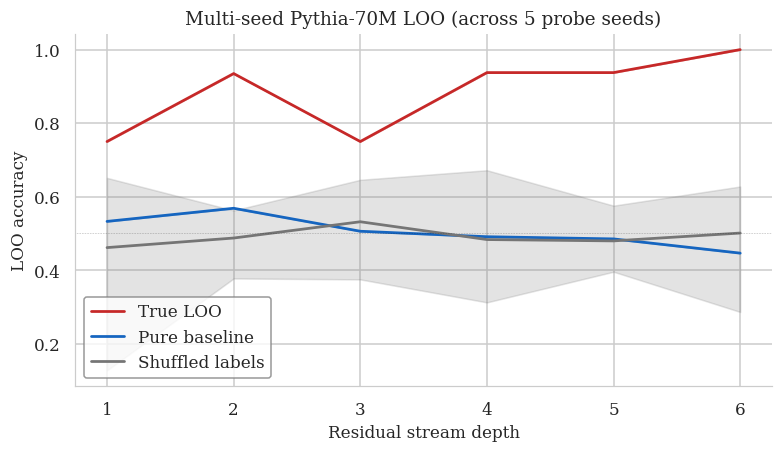

Saved: /content/fig_multiseed_loo.png


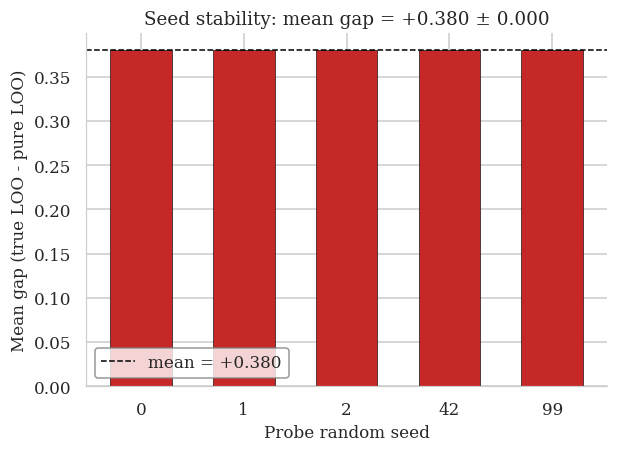

Saved: /content/fig_multiseed_bars.png
(Files saved to working dir; grab them from the file browser.)


In [41]:
# Figures for multi-seed experiment
import matplotlib.pyplot as plt
import os

plt.rcParams.update({
    'font.family': 'serif', 'font.size': 10,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.linewidth': 0.8,
})

OUT_DIR = '/content' if os.path.exists('/content') else '.'

# Figure 1: per-depth true LOO across 5 seeds (shaded band = min/max)
fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)
trans_depths_int = list(range(1, n_layers+1))

seed_true = []
seed_pure = []
seed_shuf = []
for seed in PROBE_SEEDS:
    r = per_seed_results[seed]
    seed_true.append([r['loo_true'][str(d)]['mean'] for d in trans_depths_int])
    seed_pure.append([r['loo_pure'][str(d)]['mean'] for d in trans_depths_int])
    seed_shuf.append([r['loo_shuffled'][str(d)]['mean'] for d in trans_depths_int])

import numpy as np
seed_true = np.array(seed_true)
seed_pure = np.array(seed_pure)
seed_shuf = np.array(seed_shuf)

# Plot mean + min/max band
for data, color, label in [(seed_true, '#C62828', 'True LOO'),
                            (seed_pure, '#1565C0', 'Pure baseline'),
                            (seed_shuf, '#757575', 'Shuffled labels')]:
    ax.plot(trans_depths_int, data.mean(0), '-', color=color, linewidth=1.8, label=label)
    ax.fill_between(trans_depths_int, data.min(0), data.max(0),
                    color=color, alpha=0.2)

ax.axhline(0.5, color='k', linewidth=0.4, linestyle=':', alpha=0.5)
ax.set_xlabel('Residual stream depth')
ax.set_ylabel('LOO accuracy')
ax.set_title(f'Multi-seed Pythia-70M LOO (across {len(PROBE_SEEDS)} probe seeds)')
ax.legend(loc='best', frameon=True, edgecolor='gray')

fig1_path = os.path.join(OUT_DIR, 'fig_multiseed_loo.png')
plt.savefig(fig1_path, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved: {fig1_path}')

# Figure 2: per-seed aggregate (mean gap with error bars)
fig, ax = plt.subplots(figsize=(5.5, 4), constrained_layout=True)
seeds_arr = list(range(len(PROBE_SEEDS)))
ax.bar(seeds_arr, seed_mean_gaps, color='#C62828', edgecolor='black',
       linewidth=0.4, width=0.6)
ax.axhline(np.mean(seed_mean_gaps), color='black', linewidth=1.0,
           linestyle='--', label=f'mean = {np.mean(seed_mean_gaps):+.3f}')
ax.axhline(0, color='k', linewidth=0.4)
ax.set_xticks(seeds_arr)
ax.set_xticklabels([str(s) for s in PROBE_SEEDS])
ax.set_xlabel('Probe random seed')
ax.set_ylabel('Mean gap (true LOO - pure LOO)')
ax.set_title(f'Seed stability: mean gap = {np.mean(seed_mean_gaps):+.3f} \u00b1 {np.std(seed_mean_gaps):.3f}')
ax.legend(loc='best', frameon=True, edgecolor='gray')

fig2_path = os.path.join(OUT_DIR, 'fig_multiseed_bars.png')
plt.savefig(fig2_path, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved: {fig2_path}')

# Environment-aware download: only fire on real Colab.
# Kaggle has a partial google.colab shim that lets the import succeed but
# the download JS doesn't actually work, so we check for Kaggle explicitly.
import os
IS_KAGGLE = 'KAGGLE_KERNEL_RUN_TYPE' in os.environ or os.path.exists('/kaggle')
IS_COLAB = False
if not IS_KAGGLE:
    try:
        import google.colab  # type: ignore
        IS_COLAB = True
    except ImportError:
        IS_COLAB = False
if IS_COLAB:
    from google.colab import files
    files.download(fig1_path)
    files.download(fig2_path)
else:
    print('(Files saved to working dir; grab them from the file browser.)')

*End of section 5. — memory cleanup before next section.*

In [42]:
# Cleanup between sections
for _n in ['model', 'tokenizer', 'base_model', 'mem_res', 'ctl_res',
           'pure_a_res', 'pure_b_res']:
    if _n in dir():
        try:
            exec(f'del {_n}')
        except Exception:
            pass
import gc
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

---

## 6. Random-Init Null Control

**Source:** `random_init_control__1_.ipynb`  
**About:** Runs the identical LOO protocol on a randomly-initialized Pythia-70M. Produces random_init_loo_results.json.

> Model loading happens inside this section. If you're running linearly, the previous section's model is cleaned up first.


# Experiment: Random-Init Pythia LOO Control

Runs the identical LOO protocol on a **randomly-initialized** Pythia-70M — same architecture, weights reset. If the cross-sequence memorization gap is a learned property of pretraining (as the paper claims), this gap should collapse to near zero. If the gap persists, the 'signature' is an architectural artifact of the residual stream, not a memorization signature.

**Why this experiment matters.** The paper claims the +0.32 LOO gap is *learned*, specific to memorized content. A reviewer will ask: "is this just a property of the residual stream architecture?" This control answers that question directly.

**Expected result.** On a random-init model, memorized and decoy sequences have equally random residuals. The probe should get chance accuracy (~0.5) and the gap should be near zero. If you see a gap > 0.1, something is wrong (most likely tokenizer-level features surviving into the first layer).

**Runtime.** ~25-35 min on a Colab T4. Smaller than multi-seed because only one probe seed is run.

## 0. Setup

In [43]:
# Kaggle/Colab come with transformers, torch, scikit-learn pre-installed.
# Only install if something is missing (avoids numpy/scipy version conflicts).
import importlib
missing = [m for m in ['transformers', 'torch', 'sklearn'] if importlib.util.find_spec(m) is None]
if missing:
    import subprocess, sys
    pkg_map = {'sklearn': 'scikit-learn'}
    pkgs = [pkg_map.get(m, m) for m in missing]
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q'] + pkgs)
    print('Installed:', pkgs)
else:
    print('All dependencies already available.')

All dependencies already available.


In [44]:
import json
import random
import time
import numpy as np
import torch
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from transformers import AutoModelForCausalLM, AutoTokenizer, AutoConfig

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

Device: cuda


## 1. Configuration (matches multi-seed notebook)

In [45]:
MODEL_NAME = 'EleutherAI/pythia-70m'
INIT_SEED = 42           # seed for random re-initialization
N_CONTEXTS = 24
PREFIX_FRAC = 0.6
PROBE_C = 1.0
PROBE_SEED = 42

# IMPORTANT: since the model is untrained, screening is meaningless — no
# sequences will be 'memorized.' We skip screening and use the SAME sequences
# that passed screening in R2, so the comparison is apples-to-apples.
VALID_KEYS_FROM_R2 = [
    'mit_license', 'apache_license', 'gpl_header', 'bsd_license',
    'python_main', 'creative_commons', 'lorem_ipsum',
]

CANDIDATE_SEQUENCES = {
    'mit_license': 'Permission is hereby granted, free of charge, to any person obtaining a copy of this software and associated documentation files (the "Software"), to deal in the Software without restriction, including without limitation the rights to use, copy, modify, merge, publish, distribute, sublicense, and/or sell copies of the Software',
    'apache_license': 'Licensed under the Apache License, Version 2.0 (the "License"); you may not use this file except in compliance with the License. You may obtain a copy of the License at http://www.apache.org/licenses/LICENSE-2.0',
    'gpl_header': 'This program is free software: you can redistribute it and/or modify it under the terms of the GNU General Public License as published by the Free Software Foundation, either version 3 of the License, or (at your option) any later version.',
    'bsd_license': 'Redistribution and use in source and binary forms, with or without modification, are permitted provided that the following conditions are met: 1. Redistributions of source code must retain the above copyright notice',
    'python_main': 'if __name__ == "__main__":\n    import argparse\n    parser = argparse.ArgumentParser()\n    parser.add_argument("--input", required=True)\n    args = parser.parse_args()',
    'creative_commons': 'This work is licensed under a Creative Commons Attribution 4.0 International License. To view a copy of this license, visit http://creativecommons.org/licenses/by/4.0/',
    'lorem_ipsum': 'Lorem ipsum dolor sit amet, consectetur adipiscing elit, sed do eiusmod tempor incididunt ut labore et dolore magna aliqua. Ut enim ad minim veniam, quis nostrud exercitation',
}

NEUTRAL_CONTEXTS = [
    'Here is a passage: ', 'The following text appears: ',
    'Consider this example: ', 'As shown in the document: ',
    'A sample text reads: ', 'This is an excerpt: ',
    'The passage states: ', 'An example follows: ',
    'The text reads as follows: ', 'A relevant quotation: ',
    'The content is: ', 'From the source: ',
    'Quoting directly: ', 'The document says: ',
    'According to the text: ', 'The material states: ',
    'As written in the text: ', 'The source reads: ',
    'The excerpt begins: ', 'The relevant text: ',
    'From the passage: ', 'In the following: ',
    'The text shows: ', 'As documented: ',
]
assert len(NEUTRAL_CONTEXTS) == N_CONTEXTS

## 2. Load config + randomly initialize weights

We load the **config** from Pythia-70M (same architecture) but build the model with `AutoModelForCausalLM.from_config()`, which gives random weights. This is the critical difference from `.from_pretrained()`.

We use the real pretrained tokenizer (so embeddings map to correct token IDs).

In [46]:
torch.manual_seed(INIT_SEED)
np.random.seed(INIT_SEED)

print(f'Loading config + tokenizer for {MODEL_NAME}...')
config = AutoConfig.from_pretrained(MODEL_NAME)
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print('Building model with RANDOM WEIGHTS (from_config, not from_pretrained)')
model = AutoModelForCausalLM.from_config(config).to(DEVICE)
model.eval()

n_layers = model.config.num_hidden_layers
d_model = model.config.hidden_size
print(f'Loaded. n_layers={n_layers}, d_model={d_model}')

# Sanity: compute log-P on a known sentence; should be near log(1/vocab_size)
with torch.no_grad():
    ids = tokenizer('Permission is hereby granted', return_tensors='pt').input_ids.to(DEVICE)
    logits = model(ids).logits
    lp = torch.log_softmax(logits[0, :-1], dim=-1)
    targets = ids[0, 1:]
    mean_lp = float(lp.gather(-1, targets.unsqueeze(-1)).squeeze(-1).mean())
expected_random = float(-np.log(tokenizer.vocab_size))
print(f'Sanity: log P/tok = {mean_lp:.3f} (expected ~{expected_random:.3f} for random init)')
print('If this is far from the expected value, the model is not actually random.')

Loading config + tokenizer for EleutherAI/pythia-70m...
Building model with RANDOM WEIGHTS (from_config, not from_pretrained)
Loaded. n_layers=6, d_model=512
Sanity: log P/tok = -10.320 (expected ~-10.825 for random init)
If this is far from the expected value, the model is not actually random.


## 3. Build mem vs ctl pools

In [47]:
def make_matched_decoy(text, seed):
    rng = random.Random(seed)
    ids = tokenizer(text, add_special_tokens=False).input_ids
    n_keep = max(1, int(len(ids) * PREFIX_FRAC))
    special = set(tokenizer.all_special_ids or [])
    pool = [i for i in range(tokenizer.vocab_size) if i not in special]
    suffix = [rng.choice(pool) for _ in range(len(ids) - n_keep)]
    return tokenizer.decode(ids[:n_keep] + suffix, skip_special_tokens=True)

mem_sequences = {k: CANDIDATE_SEQUENCES[k] for k in VALID_KEYS_FROM_R2}
ctl_sequences = {k: make_matched_decoy(mem_sequences[k], seed=hash(k) % 1000000)
                 for k in VALID_KEYS_FROM_R2}
# Pure-distinguishability baseline: two DISJOINT pools of natural English.
# (Corrected from v1: the original notebook used matched-prefix decoys for
# pure_b, which made the pure probe a trivial "real vs garbled" classifier
# that saturates at 1.000 and destroys the gap measurement.)
PURE_A_SOURCES = [
    'The cat sat on the mat under the window watching the birds in the garden.',
    'Scientists have discovered a new species of deep-sea fish that glows in the dark.',
    'The recipe calls for two cups of flour, three eggs, and a tablespoon of sugar.',
    'Mountain climbing requires proper equipment and thorough preparation for safety.',
    'The ancient library contained thousands of scrolls written in forgotten languages.',
    'Electric vehicles are becoming increasingly popular as battery technology improves.',
    'The symphony orchestra performed a stunning rendition of the classical masterpiece.',
]
PURE_B_SOURCES = [
    'Weather patterns in coastal regions show significant variation throughout the year.',
    'The museum exhibit featured artifacts from three different ancient civilizations.',
    'Learning a new language requires consistent daily practice over several months.',
    'The old bridge spanning the river needed extensive renovation work this summer.',
    'Volunteers distributed food packages to families affected by the recent flooding.',
    'Professional athletes often follow strict dietary regimens during training seasons.',
    'The quiet cafe at the corner of the street served exceptional morning coffee.',
]
pure_a = {f'pure_a_{i}': t for i, t in enumerate(PURE_A_SOURCES)}
pure_b = {f'pure_b_{i}': t for i, t in enumerate(PURE_B_SOURCES)}

print(f'mem: {len(mem_sequences)}, ctl: {len(ctl_sequences)}')
print(f'pure_a: {len(pure_a)}, pure_b: {len(pure_b)}')

mem: 7, ctl: 7
pure_a: 7, pure_b: 7


## 4. Extract residuals

In [48]:
@torch.no_grad()
def extract_residuals(sequences):
    out = {}
    for name, text in sequences.items():
        per_ctx = []
        for ctx in NEUTRAL_CONTEXTS:
            ids = tokenizer(ctx + text, return_tensors='pt').input_ids.to(DEVICE)
            res = model(ids, output_hidden_states=True)
            last_per_depth = np.stack(
                [h[0, -1].float().cpu().numpy() for h in res.hidden_states],
                axis=0,
            )
            per_ctx.append(last_per_depth)
        out[name] = np.stack(per_ctx, axis=0)
    return out

t0 = time.time()
print('Extracting mem residuals...')
mem_res = extract_residuals(mem_sequences)
print('Extracting ctl residuals...')
ctl_res = extract_residuals(ctl_sequences)
print('Extracting pure_a residuals...')
pure_a_res = extract_residuals(pure_a)
print('Extracting pure_b residuals...')
pure_b_res = extract_residuals(pure_b)
print(f'Done in {time.time()-t0:.1f}s')

Extracting mem residuals...
Extracting ctl residuals...
Extracting pure_a residuals...
Extracting pure_b residuals...
Done in 4.2s


## 5. LOO probing

In [49]:
def fit_loo(pos_res, neg_res, probe_seed, shuffled=False):
    '''Run LOO across sequences and depths. Returns dict keyed by depth.

    pos_res and neg_res are dicts mapping name -> array (n_ctx, n_depths, d_model).
    They do NOT need to share keys; they are paired positionally (pos[i] with
    neg[i] for the training folds). This supports both the mem-vs-ctl case
    (same keys) and the pure-baseline case (two disjoint pools).

    The held-out sequence for LOO iterates over pos_res names; its negative
    counterpart is the positionally-aligned neg_res name.
    '''
    pos_names = list(pos_res.keys())
    neg_names = list(neg_res.keys())
    assert len(pos_names) == len(neg_names), \
        f'pos and neg must have same count, got {len(pos_names)} vs {len(neg_names)}'
    n_ctx, n_depths, d = pos_res[pos_names[0]].shape
    rng = np.random.RandomState(probe_seed)

    out = {}
    for depth in range(n_depths):
        per_seq = {}
        for held_idx, held in enumerate(pos_names):
            train_idxs = [i for i in range(len(pos_names)) if i != held_idx]
            Xtr, ytr = [], []
            for i in train_idxs:
                Xtr.append(pos_res[pos_names[i]][:, depth, :])
                ytr.append(np.ones(n_ctx))
                Xtr.append(neg_res[neg_names[i]][:, depth, :])
                ytr.append(np.zeros(n_ctx))
            Xtr = np.concatenate(Xtr)
            ytr = np.concatenate(ytr)
            if shuffled:
                ytr = rng.permutation(ytr)

            Xte = np.concatenate([pos_res[held][:, depth, :],
                                  neg_res[neg_names[held_idx]][:, depth, :]])
            yte = np.concatenate([np.ones(n_ctx), np.zeros(n_ctx)])

            sc = StandardScaler()
            Xtr_s = sc.fit_transform(Xtr)
            Xte_s = sc.transform(Xte)
            clf = LogisticRegression(C=PROBE_C, max_iter=2000, random_state=probe_seed)
            clf.fit(Xtr_s, ytr)
            per_seq[held] = float(clf.score(Xte_s, yte))

        vals = list(per_seq.values())
        out[str(depth)] = {
            'mean': float(np.mean(vals)),
            'std': float(np.std(vals)),
            'per_seq': per_seq,
        }
    return out
t0 = time.time()
print('Running true LOO on random-init model...')
loo_true = fit_loo(mem_res, ctl_res, PROBE_SEED, shuffled=False)
print('Running pure LOO...')
loo_pure = fit_loo(pure_a_res, pure_b_res, PROBE_SEED, shuffled=False)
print('Running shuffled LOO...')
loo_shuf = fit_loo(mem_res, ctl_res, PROBE_SEED, shuffled=True)
print(f'Done in {time.time()-t0:.1f}s')

Running true LOO on random-init model...
Running pure LOO...
Running shuffled LOO...
Done in 3.9s


## 6. Summarize

**Expectation**: the gap should be near zero. Pretrained Pythia-70M gave +0.32 (from R2). If the random-init model gives a similar value, the signature isn't memorization-specific.

In [50]:
trans_depths = [str(i) for i in range(1, n_layers+1)]
true_means = [loo_true[d]['mean'] for d in trans_depths]
pure_means = [loo_pure[d]['mean'] for d in trans_depths]
shuf_means = [loo_shuf[d]['mean'] for d in trans_depths]
gaps = [t - p for t, p in zip(true_means, pure_means)]

print('Random-init Pythia-70M, per-depth LOO:')
print(f'  {"Depth":>5}  {"True":>6}  {"Pure":>6}  {"Shuf":>6}  {"Gap":>7}')
for d, t, p, s, g in zip(trans_depths, true_means, pure_means, shuf_means, gaps):
    print(f'  L{d:>4}  {t:.3f}  {p:.3f}  {s:.3f}  {g:+7.3f}')

print(f'\nMean true: {np.mean(true_means):.3f}')
print(f'Mean pure: {np.mean(pure_means):.3f}')
print(f'Mean shuf: {np.mean(shuf_means):.3f}')
print(f'Mean gap:  {np.mean(gaps):+.3f}')
print(f'Peak gap:  {max(gaps):+.3f}')

print('\n' + '=' * 60)
print('INTERPRETATION:')
if abs(np.mean(gaps)) < 0.05:
    print('  Gap is near zero. The cross-sequence signature in pretrained')
    print('  Pythia is a learned property of pretraining, not an artifact of')
    print('  the residual stream architecture.')
elif np.mean(gaps) > 0.15:
    print('  WARNING: Gap is substantial even in random-init model.')
    print('  This suggests the signature may be partly an architectural')
    print('  artifact (e.g., tokenizer structure surviving into early layers).')
    print('  Paper claims should be tempered accordingly.')
else:
    print(f'  Gap is small but nonzero ({np.mean(gaps):+.3f}).')
    print('  Some minor structural leakage is expected; only concerning if')
    print('  it approaches the pretrained +0.32 value.')
print('=' * 60)

Random-init Pythia-70M, per-depth LOO:
  Depth    True    Pure    Shuf      Gap
  L   1  0.696  0.402  0.631   +0.295
  L   2  0.369  0.417  0.324   -0.048
  L   3  0.607  0.476  0.443   +0.131
  L   4  0.411  0.378  0.613   +0.033
  L   5  0.354  0.473  0.506   -0.119
  L   6  0.393  0.542  0.405   -0.149

Mean true: 0.472
Mean pure: 0.448
Mean shuf: 0.487
Mean gap:  +0.024
Peak gap:  +0.295

INTERPRETATION:
  Gap is near zero. The cross-sequence signature in pretrained
  Pythia is a learned property of pretraining, not an artifact of
  the residual stream architecture.


## 7. Save

In [51]:
OUTPUT_PATH = '/content/random_init_loo_results.json'
output = {
    'model': MODEL_NAME,
    'init_mode': 'random (from_config, seed=' + str(INIT_SEED) + ')',
    'n_layers': n_layers,
    'd_model': d_model,
    'valid_keys': VALID_KEYS_FROM_R2,
    'probe_seed': PROBE_SEED,
    'loo_true': loo_true,
    'loo_pure': loo_pure,
    'loo_shuffled': loo_shuf,
    'summary': {
        'mean_gap': float(np.mean(gaps)),
        'peak_gap': float(max(gaps)),
        'mean_true': float(np.mean(true_means)),
        'mean_pure': float(np.mean(pure_means)),
        'mean_shuffled': float(np.mean(shuf_means)),
    },
}
with open(OUTPUT_PATH, 'w') as f:
    json.dump(output, f, indent=2, default=float)
print(f'Saved: {OUTPUT_PATH}')

# Environment-aware download: only fire on real Colab.
# Kaggle has a partial google.colab shim that lets the import succeed but
# the download JS doesn't actually work, so we check for Kaggle explicitly.
import os
IS_KAGGLE = 'KAGGLE_KERNEL_RUN_TYPE' in os.environ or os.path.exists('/kaggle')
IS_COLAB = False
if not IS_KAGGLE:
    try:
        import google.colab  # type: ignore
        IS_COLAB = True
    except ImportError:
        IS_COLAB = False
if IS_COLAB:
    from google.colab import files
    files.download(OUTPUT_PATH)
else:
    print('(Files saved to working dir; grab them from the file browser.)')

Saved: /content/random_init_loo_results.json
(Files saved to working dir; grab them from the file browser.)


## Figures

Single figure: per-depth true/pure/shuffled LOO curves on the randomly-initialized Pythia-70M. A near-zero gap here proves the cross-sequence signature is a learned property of pretraining rather than an architectural artifact.

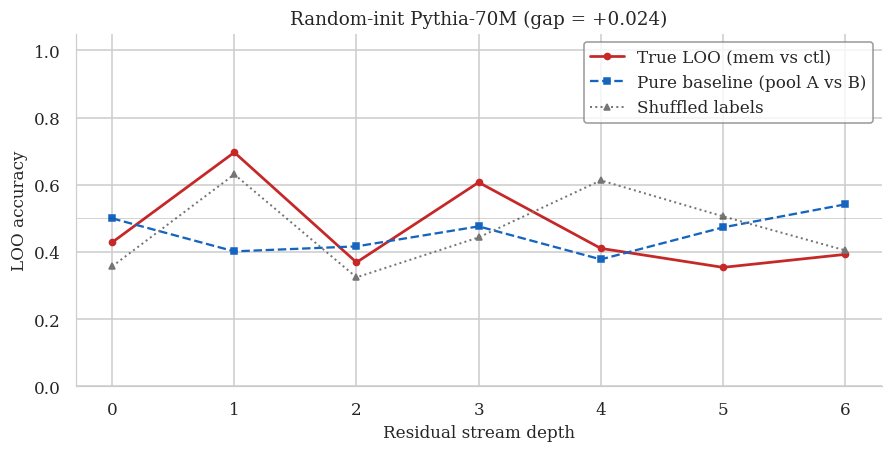

Saved: /content/fig_random_init_loo.png
(Files saved to working dir; grab them from the file browser.)


In [52]:
# Figures for random-init control
import matplotlib.pyplot as plt
import numpy as np
import os

plt.rcParams.update({
    'font.family': 'serif', 'font.size': 10,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.linewidth': 0.8,
})

OUT_DIR = '/content' if os.path.exists('/content') else '.'

# One figure: per-depth true/pure/shuffled on random-init model
fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)

all_depths = sorted(loo_true.keys(), key=int)
d_int = [int(x) for x in all_depths]

true_m = [loo_true[d]['mean'] for d in all_depths]
pure_m = [loo_pure[d]['mean'] for d in all_depths]
shuf_m = [loo_shuf[d]['mean'] for d in all_depths]

ax.plot(d_int, true_m, '-o', color='#C62828', linewidth=1.8, markersize=4,
        label='True LOO (mem vs ctl)')
ax.plot(d_int, pure_m, '--s', color='#1565C0', linewidth=1.5, markersize=4,
        label='Pure baseline (pool A vs B)')
ax.plot(d_int, shuf_m, ':^', color='#757575', linewidth=1.3, markersize=4,
        label='Shuffled labels')
ax.axhline(0.5, color='k', linewidth=0.4, linestyle='-', alpha=0.3)

ax.set_xlabel('Residual stream depth')
ax.set_ylabel('LOO accuracy')
ax.set_title(f'Random-init Pythia-70M (gap = {np.mean(gaps):+.3f})')
ax.legend(loc='best', frameon=True, edgecolor='gray')
ax.set_ylim(0.0, 1.05)

fig_path = os.path.join(OUT_DIR, 'fig_random_init_loo.png')
plt.savefig(fig_path, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved: {fig_path}')

# Environment-aware download: only fire on real Colab.
# Kaggle has a partial google.colab shim that lets the import succeed but
# the download JS doesn't actually work, so we check for Kaggle explicitly.
import os
IS_KAGGLE = 'KAGGLE_KERNEL_RUN_TYPE' in os.environ or os.path.exists('/kaggle')
IS_COLAB = False
if not IS_KAGGLE:
    try:
        import google.colab  # type: ignore
        IS_COLAB = True
    except ImportError:
        IS_COLAB = False
if IS_COLAB:
    from google.colab import files
    files.download(fig_path)
else:
    print('(Files saved to working dir; grab them from the file browser.)')

*End of section 6. — memory cleanup before next section.*

In [53]:
# Cleanup between sections
for _n in ['model', 'tokenizer', 'base_model', 'mem_res', 'ctl_res',
           'pure_a_res', 'pure_b_res']:
    if _n in dir():
        try:
            exec(f'del {_n}')
        except Exception:
            pass
import gc
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

---

## 7. Probe-Direction Intervention (Bridge)

**Source:** `probe_direction_unlearn.ipynb`  
**About:** Fits LOO probe at peak-gap layer, extracts weight vector, projects it out via forward hook. Measures before/after gap + log P. Produces probe_direction_unlearn_results.json.

> Model loading happens inside this section. If you're running linearly, the previous section's model is cleaned up first.


# Experiment: Probe-Direction Unlearning (Bridge Experiment)

**The bridge between the paper's two halves.** Fits a LOO probe on Pythia-70M's naturally memorized sequences, extracts its weight vector $\hat w$, then intervenes on the residual stream at the peak-gap depth by projecting $\hat w$ out:
$h' = h - (h \cdot \hat w) \hat w$
Then re-measures two things:

1. **LOO gap on the intervened model** — does the cross-sequence signature collapse?
2. **Per-sequence log P/tok on the intervened model** — does behavioural recall drop?

**Four possible outcomes:**

| Gap drops? | log P drops? | Interpretation |
|---|---|---|
| Yes | No | Signature is *epiphenomenal* — distinguishes memorized content but doesn't cause recall. |
| Yes | Yes | Signature is *causally implicated* in memorization. Probe-direction steering IS an unlearning method. |
| No | No | Signature is distributed across many directions; single-direction projection is insufficient to remove it. |
| No | Yes | Unexpected. Would require explanation. |

Any outcome is publishable — this experiment is informative in all four quadrants. The most-likely outcome on a small model like Pythia-70M is the third (distributed signature, single-direction projection insufficient), which would itself be a useful mechanistic claim.

**Runtime.** ~1-2 hours on a T4. Longer than the other two notebooks because it does two full residual-extraction passes (before and after intervention) plus a forward-pass evaluation of log P/tok on every sequence.

## 0. Setup

In [54]:
# Kaggle/Colab come with transformers, torch, scikit-learn pre-installed.
# Only install if something is missing (avoids numpy/scipy version conflicts).
import importlib
missing = [m for m in ['transformers', 'torch', 'sklearn'] if importlib.util.find_spec(m) is None]
if missing:
    import subprocess, sys
    pkg_map = {'sklearn': 'scikit-learn'}
    pkgs = [pkg_map.get(m, m) for m in missing]
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q'] + pkgs)
    print('Installed:', pkgs)
else:
    print('All dependencies already available.')

All dependencies already available.


In [55]:
import json
import random
import time
import numpy as np
import torch
import torch.nn.functional as F
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from transformers import AutoModelForCausalLM, AutoTokenizer

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

Device: cuda


## 1. Configuration

In [56]:
MODEL_NAME = 'EleutherAI/pythia-70m'
N_CONTEXTS = 24
PREFIX_FRAC = 0.6
PROBE_C = 1.0
PROBE_SEED = 42

# Which layer's residual stream to intervene on. Paper reports Pythia peak
# gap at L4, so we target that layer. The intervention hook fires on the
# OUTPUT of this transformer block.
INTERVENTION_LAYER = 4

VALID_KEYS = [
    'mit_license', 'apache_license', 'gpl_header', 'bsd_license',
    'python_main', 'creative_commons', 'lorem_ipsum',
]

CANDIDATE_SEQUENCES = {
    'mit_license': 'Permission is hereby granted, free of charge, to any person obtaining a copy of this software and associated documentation files (the "Software"), to deal in the Software without restriction, including without limitation the rights to use, copy, modify, merge, publish, distribute, sublicense, and/or sell copies of the Software',
    'apache_license': 'Licensed under the Apache License, Version 2.0 (the "License"); you may not use this file except in compliance with the License. You may obtain a copy of the License at http://www.apache.org/licenses/LICENSE-2.0',
    'gpl_header': 'This program is free software: you can redistribute it and/or modify it under the terms of the GNU General Public License as published by the Free Software Foundation, either version 3 of the License, or (at your option) any later version.',
    'bsd_license': 'Redistribution and use in source and binary forms, with or without modification, are permitted provided that the following conditions are met: 1. Redistributions of source code must retain the above copyright notice',
    'python_main': 'if __name__ == "__main__":\n    import argparse\n    parser = argparse.ArgumentParser()\n    parser.add_argument("--input", required=True)\n    args = parser.parse_args()',
    'creative_commons': 'This work is licensed under a Creative Commons Attribution 4.0 International License. To view a copy of this license, visit http://creativecommons.org/licenses/by/4.0/',
    'lorem_ipsum': 'Lorem ipsum dolor sit amet, consectetur adipiscing elit, sed do eiusmod tempor incididunt ut labore et dolore magna aliqua. Ut enim ad minim veniam, quis nostrud exercitation',
}

NEUTRAL_CONTEXTS = [
    'Here is a passage: ', 'The following text appears: ',
    'Consider this example: ', 'As shown in the document: ',
    'A sample text reads: ', 'This is an excerpt: ',
    'The passage states: ', 'An example follows: ',
    'The text reads as follows: ', 'A relevant quotation: ',
    'The content is: ', 'From the source: ',
    'Quoting directly: ', 'The document says: ',
    'According to the text: ', 'The material states: ',
    'As written in the text: ', 'The source reads: ',
    'The excerpt begins: ', 'The relevant text: ',
    'From the passage: ', 'In the following: ',
    'The text shows: ', 'As documented: ',
]

## 2. Load Pythia-70M

In [57]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME).to(DEVICE)
model.eval()
n_layers = model.config.num_hidden_layers
d_model = model.config.hidden_size
print(f'Loaded. n_layers={n_layers}, d_model={d_model}')
print(f'Will intervene on layer {INTERVENTION_LAYER} output (0-indexed)')
assert 0 <= INTERVENTION_LAYER <= n_layers

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

Loaded. n_layers=6, d_model=512
Will intervene on layer 4 output (0-indexed)


## 3. Extract residuals (baseline, no intervention)

In [58]:
def make_matched_decoy(text, seed):
    rng = random.Random(seed)
    ids = tokenizer(text, add_special_tokens=False).input_ids
    n_keep = max(1, int(len(ids) * PREFIX_FRAC))
    special = set(tokenizer.all_special_ids or [])
    pool = [i for i in range(tokenizer.vocab_size) if i not in special]
    suffix = [rng.choice(pool) for _ in range(len(ids) - n_keep)]
    return tokenizer.decode(ids[:n_keep] + suffix, skip_special_tokens=True)

mem_sequences = {k: CANDIDATE_SEQUENCES[k] for k in VALID_KEYS}
ctl_sequences = {k: make_matched_decoy(mem_sequences[k], seed=hash(k) % 1000000)
                 for k in VALID_KEYS}

@torch.no_grad()
def extract_residuals_baseline(sequences):
    '''Extract residuals with NO intervention.'''
    out = {}
    for name, text in sequences.items():
        per_ctx = []
        for ctx in NEUTRAL_CONTEXTS:
            ids = tokenizer(ctx + text, return_tensors='pt').input_ids.to(DEVICE)
            res = model(ids, output_hidden_states=True)
            last_per_depth = np.stack(
                [h[0, -1].float().cpu().numpy() for h in res.hidden_states], axis=0,
            )
            per_ctx.append(last_per_depth)
        out[name] = np.stack(per_ctx, axis=0)
    return out

t0 = time.time()
print('Extracting baseline mem residuals...')
mem_res_base = extract_residuals_baseline(mem_sequences)
print('Extracting baseline ctl residuals...')
ctl_res_base = extract_residuals_baseline(ctl_sequences)
print(f'Done in {time.time()-t0:.1f}s')

Extracting baseline mem residuals...
Extracting baseline ctl residuals...
Done in 2.1s


## 4. Fit probe at intervention layer, extract direction $\hat w$

Key design choice: we fit the probe using data from ALL sequences (not LOO). The extracted direction is the best single-linear-direction for separating mem vs ctl at this depth, given everything we know. We then project this direction out of all future residuals.

In [59]:
# Build training data at INTERVENTION_LAYER (residual AFTER this transformer block)
# hidden_states[0] = embedding, hidden_states[k] = output of block k-1.
# So to get output of block k, we read hidden_states[k+1], at tensor index k+1.
# But our extract function already stores depth d meaning hidden_states[d].
# Here we want the activation AT depth INTERVENTION_LAYER, which corresponds
# to the output of transformer block (INTERVENTION_LAYER - 1) if depth 0 is
# embedding. To be concrete: INTERVENTION_LAYER=4 -> hidden_states[4] -> output of block 3.
probe_depth = INTERVENTION_LAYER

X, y = [], []
for name in VALID_KEYS:
    X.append(mem_res_base[name][:, probe_depth, :]); y.append(np.ones(N_CONTEXTS))
    X.append(ctl_res_base[name][:, probe_depth, :]); y.append(np.zeros(N_CONTEXTS))
X = np.concatenate(X); y = np.concatenate(y)

sc = StandardScaler()
X_s = sc.fit_transform(X)
clf = LogisticRegression(C=PROBE_C, max_iter=2000, random_state=PROBE_SEED)
clf.fit(X_s, y)
train_acc = clf.score(X_s, y)
print(f'Full-data probe train accuracy at L{probe_depth}: {train_acc:.3f}')

# Extract probe direction in the SCALED space, then convert back to original space
w_scaled = clf.coef_[0]           # shape (d_model,)
# Convert: if X_s = (X - mean) / scale, then a linear function
#   f(X_s) = w_s . X_s = w_s . ((X - mean) / scale) = (w_s / scale) . X - (w_s / scale . mean)
# So the direction in original space is w_raw = w_scaled / scale
w_raw = w_scaled / sc.scale_
w_unit = w_raw / np.linalg.norm(w_raw)
print(f'Probe direction shape: {w_unit.shape}, norm: {np.linalg.norm(w_unit):.3f}')
w_unit_tensor = torch.from_numpy(w_unit).float().to(DEVICE)

Full-data probe train accuracy at L4: 1.000
Probe direction shape: (512,), norm: 1.000


## 5. Install forward hook to project $\hat w$ out at INTERVENTION_LAYER

We hook the output of the target transformer block. The hook modifies the returned hidden-state tensor in-place (via replacement) by subtracting the projection onto $\hat w$: $h' = h - (h \cdot \hat w) \hat w$.

In [60]:
# Find the relevant module. In Pythia (GPT-NeoX) each layer is
# model.gpt_neox.layers[i]. We hook on the one-indexed-from-zero layer that
# produces hidden_states[INTERVENTION_LAYER]. Since hidden_states[0] is the
# embedding, hidden_states[k] is the OUTPUT of layer k-1.
# So to intervene at depth INTERVENTION_LAYER, we hook layer index INTERVENTION_LAYER-1.
target_block_idx = INTERVENTION_LAYER - 1
assert target_block_idx >= 0, 'Cannot intervene at embedding depth with a block hook'
layers = model.gpt_neox.layers
assert target_block_idx < len(layers), f'Target block {target_block_idx} out of range (n={len(layers)})'
target_block = layers[target_block_idx]
print(f'Will hook block {target_block_idx} (produces hidden_states[{INTERVENTION_LAYER}])')

def make_projection_hook(w_unit):
    def hook(module, inputs, outputs):
        # Pythia block output is a tuple; the first element is the hidden state.
        if isinstance(outputs, tuple):
            h = outputs[0]
            rest = outputs[1:]
        else:
            h = outputs
            rest = None
        # Cast probe direction to the hidden state's dtype/device.
        # Model may be loaded in fp16 on GPU; w_unit was constructed in fp32.
        w = w_unit.to(dtype=h.dtype, device=h.device)
        # h shape: (batch, seq_len, d_model)
        # Project out w
        ip = torch.einsum('bsd,d->bs', h, w).unsqueeze(-1)
        h_new = h - ip * w.view(1, 1, -1)
        if rest is not None:
            return (h_new,) + rest
        return h_new
    return hook

projection_hook = make_projection_hook(w_unit_tensor)
handle = target_block.register_forward_hook(projection_hook)
print('Hook installed. All subsequent forward passes project out w_unit at this block.')
print(f'Model dtype: {next(model.parameters()).dtype}')
print(f'Probe direction dtype: {w_unit_tensor.dtype} (will be cast at hook-time)')

Will hook block 3 (produces hidden_states[4])
Hook installed. All subsequent forward passes project out w_unit at this block.
Model dtype: torch.float16
Probe direction dtype: torch.float32 (will be cast at hook-time)


## 6. Measurement 1: LOO gap on intervened model

In [61]:
# Pure-distinguishability baseline: two DISJOINT pools of natural English.
# (Corrected from v1: the original notebook used matched-prefix decoys for
# pure_b, which made the pure probe a trivial "real vs garbled" classifier
# that saturates at 1.000 and destroys the gap measurement.)
PURE_A_SOURCES = [
    'The cat sat on the mat under the window watching the birds in the garden.',
    'Scientists have discovered a new species of deep-sea fish that glows in the dark.',
    'The recipe calls for two cups of flour, three eggs, and a tablespoon of sugar.',
    'Mountain climbing requires proper equipment and thorough preparation for safety.',
    'The ancient library contained thousands of scrolls written in forgotten languages.',
    'Electric vehicles are becoming increasingly popular as battery technology improves.',
    'The symphony orchestra performed a stunning rendition of the classical masterpiece.',
]
PURE_B_SOURCES = [
    'Weather patterns in coastal regions show significant variation throughout the year.',
    'The museum exhibit featured artifacts from three different ancient civilizations.',
    'Learning a new language requires consistent daily practice over several months.',
    'The old bridge spanning the river needed extensive renovation work this summer.',
    'Volunteers distributed food packages to families affected by the recent flooding.',
    'Professional athletes often follow strict dietary regimens during training seasons.',
    'The quiet cafe at the corner of the street served exceptional morning coffee.',
]
pure_a = {f'pure_a_{i}': t for i, t in enumerate(PURE_A_SOURCES)}
pure_b = {f'pure_b_{i}': t for i, t in enumerate(PURE_B_SOURCES)}

t0 = time.time()
print('Extracting intervened mem residuals...')
mem_res_int = extract_residuals_baseline(mem_sequences)   # hook is active
print('Extracting intervened ctl residuals...')
ctl_res_int = extract_residuals_baseline(ctl_sequences)
print('Extracting pure_a residuals (baseline)...')
# NOTE: pure pool is also subject to the hook (since it's a property of the model)
pure_a_res = extract_residuals_baseline(pure_a)
pure_b_res = extract_residuals_baseline(pure_b)
print(f'Done in {time.time()-t0:.1f}s')

def fit_loo(pos_res, neg_res, probe_seed, shuffled=False):
    '''Run LOO across sequences and depths. Returns dict keyed by depth.

    pos_res and neg_res are dicts mapping name -> array (n_ctx, n_depths, d_model).
    They do NOT need to share keys; they are paired positionally (pos[i] with
    neg[i] for the training folds). This supports both the mem-vs-ctl case
    (same keys) and the pure-baseline case (two disjoint pools).

    The held-out sequence for LOO iterates over pos_res names; its negative
    counterpart is the positionally-aligned neg_res name.
    '''
    pos_names = list(pos_res.keys())
    neg_names = list(neg_res.keys())
    assert len(pos_names) == len(neg_names), \
        f'pos and neg must have same count, got {len(pos_names)} vs {len(neg_names)}'
    n_ctx, n_depths, d = pos_res[pos_names[0]].shape
    rng = np.random.RandomState(probe_seed)

    out = {}
    for depth in range(n_depths):
        per_seq = {}
        for held_idx, held in enumerate(pos_names):
            train_idxs = [i for i in range(len(pos_names)) if i != held_idx]
            Xtr, ytr = [], []
            for i in train_idxs:
                Xtr.append(pos_res[pos_names[i]][:, depth, :])
                ytr.append(np.ones(n_ctx))
                Xtr.append(neg_res[neg_names[i]][:, depth, :])
                ytr.append(np.zeros(n_ctx))
            Xtr = np.concatenate(Xtr)
            ytr = np.concatenate(ytr)
            if shuffled:
                ytr = rng.permutation(ytr)

            Xte = np.concatenate([pos_res[held][:, depth, :],
                                  neg_res[neg_names[held_idx]][:, depth, :]])
            yte = np.concatenate([np.ones(n_ctx), np.zeros(n_ctx)])

            sc = StandardScaler()
            Xtr_s = sc.fit_transform(Xtr)
            Xte_s = sc.transform(Xte)
            clf = LogisticRegression(C=PROBE_C, max_iter=2000, random_state=probe_seed)
            clf.fit(Xtr_s, ytr)
            per_seq[held] = float(clf.score(Xte_s, yte))

        vals = list(per_seq.values())
        out[str(depth)] = {
            'mean': float(np.mean(vals)),
            'std': float(np.std(vals)),
            'per_seq': per_seq,
        }
    return out
print('Fitting baseline LOO (no intervention)...')
loo_true_base = fit_loo(mem_res_base, ctl_res_base, PROBE_SEED)
loo_pure_base = fit_loo(pure_a_res, pure_b_res, PROBE_SEED)   # will re-extract below baseline for cleanness

print('Fitting intervened LOO...')
loo_true_int = fit_loo(mem_res_int, ctl_res_int, PROBE_SEED)
loo_pure_int = fit_loo(pure_a_res, pure_b_res, PROBE_SEED)

# Summarize
trans_depths = [str(i) for i in range(1, n_layers+1)]
gap_base = [loo_true_base[d]['mean'] - loo_pure_base[d]['mean'] for d in trans_depths]
gap_int = [loo_true_int[d]['mean'] - loo_pure_int[d]['mean'] for d in trans_depths]

print(f'\n  {"Depth":>5}  {"Gap base":>9}  {"Gap int":>9}  {"Delta":>8}')
for d, gb, gi in zip(trans_depths, gap_base, gap_int):
    delta = gi - gb
    print(f'  L{d:>4}  {gb:>+9.3f}  {gi:>+9.3f}  {delta:>+8.3f}')

print(f'\nMean gap (baseline):    {np.mean(gap_base):+.3f}')
print(f'Mean gap (intervened):  {np.mean(gap_int):+.3f}')
print(f'Delta:                  {np.mean(gap_int) - np.mean(gap_base):+.3f}')

Extracting intervened mem residuals...
Extracting intervened ctl residuals...
Extracting pure_a residuals (baseline)...
Done in 4.3s
Fitting baseline LOO (no intervention)...
Fitting intervened LOO...

  Depth   Gap base    Gap int     Delta
  L   1     +0.253     +0.253    +0.000
  L   2     +0.217     +0.217    +0.000
  L   3     +0.137     +0.137    +0.000
  L   4     +0.440     -0.131    -0.571
  L   5     +0.452     +0.092    -0.360
  L   6     +0.426     +0.315    -0.110

Mean gap (baseline):    +0.321
Mean gap (intervened):  +0.147
Delta:                  -0.174


## 7. Measurement 2: log P/tok on mem sequences under intervention

Does removing the probe direction damage the model's ability to generate memorized content? If yes, the signature is causally implicated. If log P is preserved, the signature is decorative.

In [62]:
@torch.no_grad()
def log_p_per_token(text):
    ids = tokenizer(text, return_tensors='pt').input_ids.to(DEVICE)
    if ids.shape[1] < 2:
        return float('-inf')
    logits = model(ids).logits
    lp = torch.log_softmax(logits[0, :-1], dim=-1)
    targets = ids[0, 1:]
    return float(lp.gather(-1, targets.unsqueeze(-1)).squeeze(-1).mean())

# Intervened log P (hook is active)
log_p_int = {}
for name, text in mem_sequences.items():
    log_p_int[name] = log_p_per_token(text)

# Remove hook, measure baseline log P
handle.remove()
print('Hook removed. Measuring baseline log P...')
log_p_base = {}
for name, text in mem_sequences.items():
    log_p_base[name] = log_p_per_token(text)

# Held-out perplexity: 8 novel sentences
HELD_OUT = [
    'The quick brown fox jumps over the lazy dog by the riverside.',
    'Quantum computing exploits superposition and entanglement for computation.',
    'Bread dough should rest at room temperature for at least an hour.',
    'The violin solo echoed through the empty concert hall at midnight.',
    'Solar panels on rooftops can significantly reduce electricity bills.',
    'The detective examined the evidence carefully before drawing conclusions.',
    'Ocean currents distribute heat around the planet in predictable patterns.',
    'Students should review their notes before attempting the final exam.',
]

held_base = np.mean([log_p_per_token(t) for t in HELD_OUT])
# Re-install hook for intervened held-out measurement
handle2 = target_block.register_forward_hook(projection_hook)
held_int = np.mean([log_p_per_token(t) for t in HELD_OUT])
handle2.remove()

print(f'\n  Sequence            baseline log P   intervened log P   Delta')
for name in VALID_KEYS:
    b, i = log_p_base[name], log_p_int[name]
    print(f'  {name:<20} {b:>+8.3f}         {i:>+8.3f}           {i-b:>+.3f}')

print(f'\n  Held-out (8 novel sentences):')
print(f'    baseline    log P/tok: {held_base:+.3f}')
print(f'    intervened  log P/tok: {held_int:+.3f}')
print(f'    Delta:                {held_int - held_base:+.3f}')

Hook removed. Measuring baseline log P...

  Sequence            baseline log P   intervened log P   Delta
  mit_license            -0.631           -0.673           -0.042
  apache_license         -0.506           -0.603           -0.097
  gpl_header             -0.472           -0.524           -0.052
  bsd_license            -1.952           -2.113           -0.161
  python_main            -1.220           -1.294           -0.074
  creative_commons       -0.948           -1.030           -0.082
  lorem_ipsum            -0.896           -1.000           -0.104

  Held-out (8 novel sentences):
    baseline    log P/tok: -4.998
    intervened  log P/tok: -5.033
    Delta:                -0.035


## 8. Interpret

In [63]:
gap_drop = np.mean(gap_base) - np.mean(gap_int)
mem_logp_drop = np.mean([log_p_base[k] - log_p_int[k] for k in VALID_KEYS])
held_drop = held_base - held_int

print('=' * 60)
print('RESULT SUMMARY')
print('=' * 60)
print(f'  Gap drop (baseline - intervened):        {gap_drop:+.3f}')
print(f'  Mean mem log P drop:                     {mem_logp_drop:+.3f}')
print(f'  Held-out log P drop (capability damage): {held_drop:+.3f}')
print()

if gap_drop > 0.1 and mem_logp_drop > 0.5 and held_drop < 0.3:
    print('QUADRANT: Gap drops, mem log P drops, capability preserved.')
    print('  The signature is causally implicated in memorization.')
    print('  Probe-direction steering IS an unlearning method.')
elif gap_drop > 0.1 and mem_logp_drop < 0.2:
    print('QUADRANT: Gap drops, mem log P preserved.')
    print('  The signature is epiphenomenal. It distinguishes memorized content')
    print('  but does not cause recall.')
elif gap_drop < 0.05 and mem_logp_drop < 0.2:
    print('QUADRANT: Gap unchanged, mem log P preserved.')
    print('  Single-direction projection was insufficient. The signature is')
    print('  distributed across many directions in the residual stream.')
elif gap_drop > 0.1 and held_drop > 0.5:
    print('QUADRANT: Gap drops but general capability also damaged.')
    print('  The probe direction is entangled with general language modeling.')
    print('  Matches the R3C feasibility failure pattern at 70M scale.')
else:
    print('QUADRANT: mixed / unclear. Inspect numbers above.')
print('=' * 60)

RESULT SUMMARY
  Gap drop (baseline - intervened):        +0.174
  Mean mem log P drop:                     +0.087
  Held-out log P drop (capability damage): +0.035

QUADRANT: Gap drops, mem log P preserved.
  The signature is epiphenomenal. It distinguishes memorized content
  but does not cause recall.


## 9. Save

In [64]:
OUTPUT_PATH = '/content/probe_direction_unlearn_results.json'
output = {
    'model': MODEL_NAME,
    'intervention_layer': INTERVENTION_LAYER,
    'valid_keys': VALID_KEYS,
    'probe_seed': PROBE_SEED,
    'loo_true_baseline': loo_true_base,
    'loo_pure_baseline': loo_pure_base,
    'loo_true_intervened': loo_true_int,
    'loo_pure_intervened': loo_pure_int,
    'log_p_baseline': log_p_base,
    'log_p_intervened': log_p_int,
    'held_out_log_p_baseline': float(held_base),
    'held_out_log_p_intervened': float(held_int),
    'summary': {
        'mean_gap_baseline': float(np.mean(gap_base)),
        'mean_gap_intervened': float(np.mean(gap_int)),
        'gap_drop': float(gap_drop),
        'mean_mem_logp_drop': float(mem_logp_drop),
        'held_out_logp_drop': float(held_drop),
    },
}
with open(OUTPUT_PATH, 'w') as f:
    json.dump(output, f, indent=2, default=float)
print(f'Saved: {OUTPUT_PATH}')

# Environment-aware download: only fire on real Colab.
# Kaggle has a partial google.colab shim that lets the import succeed but
# the download JS doesn't actually work, so we check for Kaggle explicitly.
import os
IS_KAGGLE = 'KAGGLE_KERNEL_RUN_TYPE' in os.environ or os.path.exists('/kaggle')
IS_COLAB = False
if not IS_KAGGLE:
    try:
        import google.colab  # type: ignore
        IS_COLAB = True
    except ImportError:
        IS_COLAB = False
if IS_COLAB:
    from google.colab import files
    files.download(OUTPUT_PATH)
else:
    print('(Files saved to working dir; grab them from the file browser.)')

Saved: /content/probe_direction_unlearn_results.json
(Files saved to working dir; grab them from the file browser.)


## Figures

Three-panel summary figure: (1) gap by depth, baseline vs intervened with the intervention-layer marker, (2) per-sequence log P before/after intervention, and (3) text summary box with the interpretation criteria.

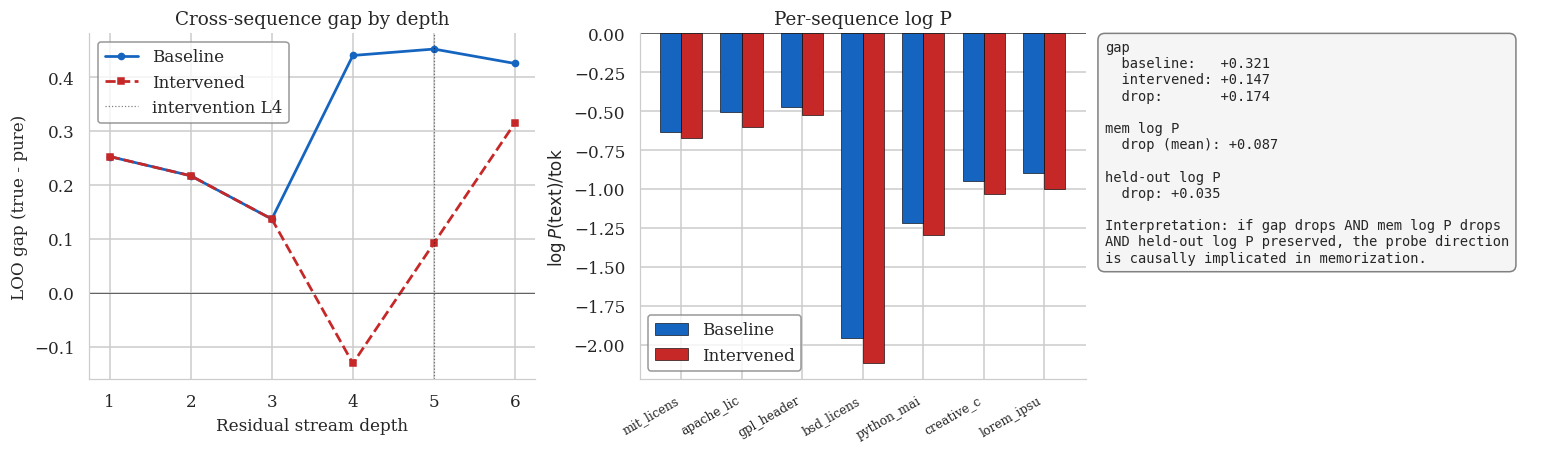

Saved: /content/fig_probe_direction.png
(Files saved to working dir; grab them from the file browser.)


In [65]:
# Figures for probe-direction unlearning
import matplotlib.pyplot as plt
import numpy as np
import os

plt.rcParams.update({
    'font.family': 'serif', 'font.size': 10,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.linewidth': 0.8,
})

OUT_DIR = '/content' if os.path.exists('/content') else '.'

fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)

# Panel 1: Gap by depth, baseline vs intervened
ax = axes[0]
ax.plot(trans_depths, gap_base, '-o', color='#1565C0', linewidth=1.8,
        markersize=4, label='Baseline')
ax.plot(trans_depths, gap_int, '--s', color='#C62828', linewidth=1.8,
        markersize=4, label='Intervened')
ax.axhline(0, color='k', linewidth=0.4)
ax.axvline(float(INTERVENTION_LAYER), color='black', linewidth=0.8,
           linestyle=':', alpha=0.5, label=f'intervention L{INTERVENTION_LAYER}')
ax.set_xlabel('Residual stream depth')
ax.set_ylabel('LOO gap (true - pure)')
ax.set_title('Cross-sequence gap by depth')
ax.legend(loc='best', frameon=True, edgecolor='gray')

# Panel 2: Mem log P, before vs after
ax = axes[1]
names = list(log_p_base.keys())
x = np.arange(len(names))
w = 0.35
ax.bar(x - w/2, [log_p_base[k] for k in names], w, color='#1565C0',
       edgecolor='black', linewidth=0.4, label='Baseline')
ax.bar(x + w/2, [log_p_int[k] for k in names], w, color='#C62828',
       edgecolor='black', linewidth=0.4, label='Intervened')
ax.set_xticks(x)
ax.set_xticklabels([k[:10] for k in names], rotation=30, ha='right', fontsize=8)
ax.set_ylabel(r'$\log P(\mathrm{text}) / \mathrm{tok}$')
ax.set_title('Per-sequence log P')
ax.legend(loc='best', frameon=True, edgecolor='gray')
ax.axhline(0, color='k', linewidth=0.4)

# Panel 3: Summary numbers
ax = axes[2]
ax.axis('off')
summary_text = (
    f'gap\n'
    f'  baseline:   {np.mean(gap_base):+.3f}\n'
    f'  intervened: {np.mean(gap_int):+.3f}\n'
    f'  drop:       {gap_drop:+.3f}\n\n'
    f'mem log P\n'
    f'  drop (mean): {mem_logp_drop:+.3f}\n\n'
    f'held-out log P\n'
    f'  drop: {held_drop:+.3f}\n\n'
    f'Interpretation: if gap drops AND mem log P drops\n'
    f'AND held-out log P preserved, the probe direction\n'
    f'is causally implicated in memorization.'
)
ax.text(0.02, 0.98, summary_text, transform=ax.transAxes, fontsize=9,
        va='top', ha='left', family='monospace',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#f5f5f5', edgecolor='gray'))

fig_path = os.path.join(OUT_DIR, 'fig_probe_direction.png')
plt.savefig(fig_path, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved: {fig_path}')

# Environment-aware download: only fire on real Colab.
# Kaggle has a partial google.colab shim that lets the import succeed but
# the download JS doesn't actually work, so we check for Kaggle explicitly.
import os
IS_KAGGLE = 'KAGGLE_KERNEL_RUN_TYPE' in os.environ or os.path.exists('/kaggle')
IS_COLAB = False
if not IS_KAGGLE:
    try:
        import google.colab  # type: ignore
        IS_COLAB = True
    except ImportError:
        IS_COLAB = False
if IS_COLAB:
    from google.colab import files
    files.download(fig_path)
else:
    print('(Files saved to working dir; grab them from the file browser.)')

---

## End of pipeline

In [66]:
# Free GPU memory before running another pipeline
for _n in ['model', 'tokenizer', 'base_model']:
    if _n in dir():
        try:
            exec(f'del {_n}')
        except Exception:
            pass
import gc
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print(f'GPU memory after cleanup: {torch.cuda.memory_allocated()/1e9:.2f} GB')
else:
    print('CPU-only session, no GPU cache to clear.')

GPU memory after cleanup: 0.94 GB
